# Class 11a: Spectral Properties and Linear Algebra, Part 1

**CNET 5052 — Spring 2026**

---

1. Explain why a network's **spectrum** is like a fingerprint — what it reveals and why we care.
2. Put a **signal** on the nodes of a graph and measure how **smooth** or **rough** it is.
3. Say what an **eigenvalue** and **eigenvector** are — in plain language, with pictures, *and* in math.
4. Name the **four main graph matrices** and know which question each one answers.
5. Read a **Laplacian spectrum** and connect it to components, bottlenecks, and vibrations.

---

1. Come in. Sit down. Open Teams.
2. Find your notebook in your `/Class_11/` folder.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scipy
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla

from IPython.display import display

rng = np.random.default_rng(5052)
np.set_printoptions(precision=4, suppress=True)

In [2]:
# ── structural helpers ──

def stable_nodelist(G, nodelist=None):
    """Return a reproducible node ordering."""
    if nodelist is not None:
        return list(nodelist)
    try:
        return sorted(G.nodes())
    except TypeError:
        return list(G.nodes())

def adjacency_dense(G, nodelist=None, weight=None, dtype=float):
    """Dense adjacency matrix with a fixed node ordering."""
    nodes = stable_nodelist(G, nodelist)
    A = nx.to_numpy_array(G, nodelist=nodes, weight=weight, dtype=dtype)
    return A, nodes

In [3]:
# ── display helpers ──

def show_matrix_df(A, name=None, index=None, columns=None, digits=3):
    """Display a small matrix as a labeled pandas DataFrame."""
    Ad = A.toarray() if sp.issparse(A) else np.asarray(A)
    m, n = Ad.shape
    if index is None:
        index = list(range(m))
    if columns is None:
        columns = list(range(n))
    df = pd.DataFrame(np.round(Ad, digits), index=index, columns=columns)
    if name:
        print(name)
    display(df)

def plot_matrix_heatmap(A, ax, title="", ticklabels=None, annotate=False):
    """Heatmap for a small matrix with optional entry annotations."""
    Ad = A.toarray() if sp.issparse(A) else np.asarray(A)
    im = ax.imshow(Ad, aspect="equal")
    ax.set_title(title)
    ax.set_xlabel("column index")
    ax.set_ylabel("row index")
    if ticklabels is not None:
        ax.set_xticks(np.arange(len(ticklabels)))
        ax.set_yticks(np.arange(len(ticklabels)))
        ax.set_xticklabels(ticklabels)
        ax.set_yticklabels(ticklabels)
    if annotate and Ad.shape[0] <= 8 and Ad.shape[1] <= 8:
        for i in range(Ad.shape[0]):
            for j in range(Ad.shape[1]):
                ax.text(j, i, f"{Ad[i, j]:.0f}", ha="center", va="center")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def draw_graph(G, ax, pos=None, values=None, title="", with_labels=True,
               node_size=250, cmap="viridis", vmin=None, vmax=None):
    """Draw a graph, optionally colored by a node signal."""
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
    if values is None:
        nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                                       node_color='.9', edgecolors='.1')
    else:
        values = np.asarray(values)
        nodes = nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=values, cmap=cmap, node_size=node_size,
            vmin=vmin, vmax=vmax,
        )
        ax.figure.colorbar(nodes, ax=ax, fraction=0.046, pad=0.04)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.6)
    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
    ax.set_title(title)
    ax.set_axis_off()
    return pos

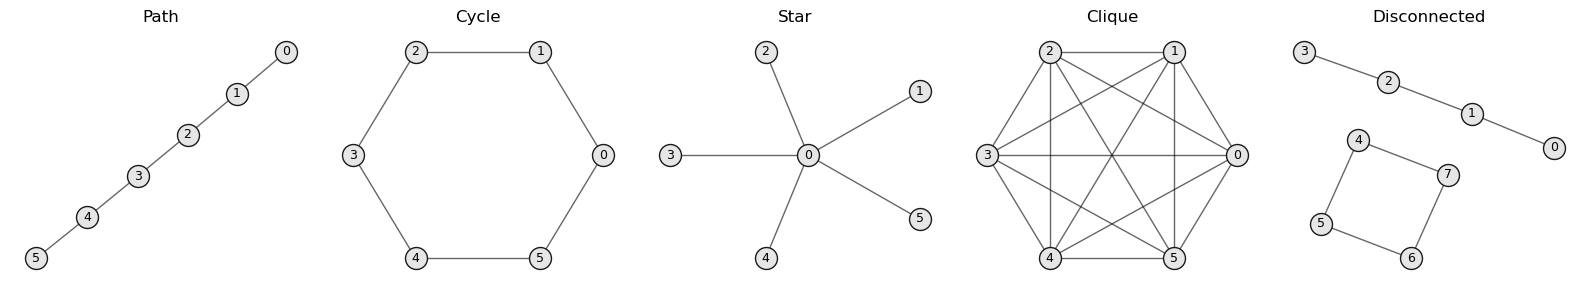

In [4]:
# ── toy graphs we will use throughout ──

G_path6 = nx.path_graph(6)
G_cycle6 = nx.cycle_graph(6)
G_star6 = nx.star_graph(5)          # node 0 is the hub
G_clique6 = nx.complete_graph(6)
G_disc = nx.disjoint_union(nx.path_graph(4), nx.cycle_graph(4))

fig, axes = plt.subplots(1, 5, figsize=(16, 3), dpi=100)
draw_graph(G_path6, axes[0], title="Path")
draw_graph(G_cycle6, axes[1], title="Cycle")
draw_graph(G_star6, axes[2], title="Star")
draw_graph(G_clique6, axes[3], title="Clique")
draw_graph(G_disc, axes[4], title="Disconnected")
plt.tight_layout()
plt.show()

---

# Part 0 — Every Object Has a Spectrum

Before we touch any math, let's build an intuition for what "spectrum" even means.

## 0.1 Spectroscopy: reading an object without opening it

### The basic idea

Imagine you find a mysterious rock in space. You can't break it open. But you **can** shine light through it and look at what comes out the other side.

Different elements absorb different frequencies of light. So the pattern of bright and dark lines — the **emission spectrum** — tells you what the rock is made of, without ever looking inside.

![](images/Hydrogen_spectrum.svg.png)

*The emission spectrum of hydrogen. Each bright line corresponds to a specific electron transition — a specific frequency of light. This pattern is unique to hydrogen; no other element produces it.*

This is [spectroscopy](https://en.wikipedia.org/wiki/Spectroscopy). It is arguably one of the most powerful ideas in all of science:

> **Shoot a signal through an object. The frequencies that survive tell you what the object is made of.**

### Why this works: resonance and natural frequencies

Every physical system has **natural frequencies** — specific rates at which it prefers to vibrate. When you send energy through the system, the frequencies that match a natural frequency get amplified (resonance); the ones that don't get dampened.

The set of all natural frequencies is the system's **spectrum**. It's determined entirely by the system's internal structure.

| System | What you probe with | What the spectrum reveals |
|:---|:---|:---|
| Chemical element | Light | Electron energy levels → element identity |
| Musical instrument | Sound | Overtone series → instrument timbre |
| Building or bridge | Mechanical vibration | Structural modes → engineering weaknesses |
| Quantum particle | Energy | Allowed energy levels → atomic orbitals |

We'll eventually see that networks have spectra too — but the idea is much more general than that. First, let's build the intuition.


### The math (preview)

Why does "finding natural frequencies" become a math problem?

A natural vibration is a pattern that **sustains itself** — after the system evolves for one time step, you get the same pattern back, possibly louder or quieter. If $M$ is the operator that describes one step of evolution, and $\mathbf{v}$ is a vibration pattern, then "sustains itself" means:

$$M\mathbf{v} = \lambda \mathbf{v}$$

The pattern $\mathbf{v}$ goes in, and the same pattern $\mathbf{v}$ comes back out — just scaled by some factor $\lambda$. That factor is the **frequency** (or energy, or growth rate, depending on the system).

- $\mathbf{v}$ is called an **eigenvector** — a self-sustaining pattern.
- $\lambda$ is called an **eigenvalue** — the scale factor for that pattern.

The collection of all eigenvalues $\{\lambda_1, \lambda_2, \ldots, \lambda_n\}$ is the **spectrum**.

This same equation shows up in quantum mechanics, structural engineering, Google's PageRank, population biology, and yes — network science. We'll build up to it step by step, starting with the basics of vectors and matrices.

## 0.2 Hearing the shape of a drum

### The question

In 1966, the mathematician [Mark Kac](https://en.wikipedia.org/wiki/Mark_Kac) published a paper with one of the most evocative titles in mathematics:

> **"Can One Hear the Shape of a Drum?"** — *Mark Kac, The American Mathematical Monthly, 1966*

The question: if you close your eyes and listen to a drum, can you figure out its shape purely from the sound?

### Why drums have spectra

When you strike a drum, its membrane vibrates. But it can't vibrate in just any pattern — the **boundary** (the rim of the drum) constrains the vibration. The membrane must be stationary at the rim and can only vibrate in specific patterns called **modes**.

<img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/Drum_vibration_mode12.gif" alt="Drum vibration mode" width="300"/>

*A vibration mode of a circular drum. The membrane oscillates up and down in a fixed pattern. Different modes have different spatial complexity and different frequencies.*


Each mode has its own frequency:
- The **fundamental mode** (lowest frequency): the whole membrane moves up and down together. The simplest possible vibration.
- The **first overtone** (higher frequency): the membrane is divided into two regions that vibrate in opposite directions. More complex, faster.
- **Higher overtones**: increasingly complex patterns, increasingly high frequencies.

The set of all these frequencies is the drum's **spectrum**. It's a fingerprint of the drum's geometry.

### What the spectrum encodes

Remarkably, the spectrum encodes a great deal of geometric information. From the eigenvalues alone, you can recover:

- The **area** of the drum (from the asymptotic growth of eigenvalues — this is [Weyl's law](https://en.wikipedia.org/wiki/Weyl_law), 1911)
- The **perimeter** (from the next-order correction)
- The **number of holes** (from the spectral asymptotics — related to the [Euler characteristic](https://en.wikipedia.org/wiki/Euler_characteristic))

### The answer (and what it means for us)

So can you hear the shape of a drum? **Almost, but not quite.** In 1992, Gordon, Webb, and Wolpert constructed two different drum shapes with *identical* spectra — you literally cannot tell them apart by listening. But such examples are rare and exotic. For *most* shapes, the spectrum uniquely determines the geometry.

The same will be true for networks:
- The spectrum captures a huge amount of structural information.
- It's a much richer invariant than simple statistics like the degree sequence.
- But it's not *perfect* — there exist non-isomorphic graphs with identical spectra (called **cospectral graphs**).

### The key takeaway

$$\boxed{\text{Geometry} \longrightarrow \text{constrains vibration patterns} \longrightarrow \text{determines the spectrum}}$$

A network is a discrete geometry. Its nodes and edges constrain which "vibration patterns" (signals on nodes) are natural. The eigenvalues of the network's matrices are the frequencies of those patterns. **The spectrum is a compressed summary of the network's shape.**

---

# Part 1 — Linear Algebra Fundamentals

What do you actually need to know about linear algebra to understand eigenvalues? Not as much as you might think. We need **vectors**, **matrices**, and one operation: **matrix-vector multiplication**.

If you've seen linear algebra before, treat this as a refresher. If you haven't, this is your introduction — and we'll go slowly.

## 1.1 Vectors: lists of numbers

### What is a vector?

What's a vector? Just an ordered list of numbers.

$$\mathbf{x} = \begin{pmatrix} 72 \\ 68 \\ 75 \\ 70 \end{pmatrix}$$

These could be anything: temperatures in four cities, pixel brightnesses in an image, stock prices, survey responses. The key is that *the order matters* — the first entry goes with the first "thing," the second with the second, etc.

### Example: temperatures

| Index | City | Temperature (°F) |
|:---:|:---|:---:|
| 0 | Boston | 72 |
| 1 | New York | 68 |
| 2 | Miami | 75 |
| 3 | Chicago | 70 |

The temperature vector $\mathbf{x} = (72, 68, 75, 70)$ assigns one number to each city. Later, when these cities are nodes in a network, we'll call this a "signal on the nodes" — but for now, it's just a list of measurements.

In [5]:
# Creating vectors in NumPy
temperatures = np.array([72, 68, 75, 70])
print("temperatures =", temperatures)
print("Type:", type(temperatures))
print("Shape:", temperatures.shape)     # (4,) means "1D array with 4 entries"
print()

# Accessing entries (0-indexed!)
print("Node 0 (Boston):", temperatures[0])
print("Node 2 (Miami):", temperatures[2])
print("Last node:", temperatures[-1])    # negative indexing works too
print()

# Useful constructors
print("Zeros:", np.zeros(4))
print("Ones: ", np.ones(4))
print("Range:", np.arange(4))

temperatures = [72 68 75 70]
Type: <class 'numpy.ndarray'>
Shape: (4,)

Node 0 (Boston): 72
Node 2 (Miami): 75
Last node: 70

Zeros: [0. 0. 0. 0.]
Ones:  [1. 1. 1. 1.]
Range: [0 1 2 3]


### Vector arithmetic

You can add vectors and multiply them by numbers. These work **entry by entry**.

$$\mathbf{x} + \mathbf{y} = \begin{pmatrix} x_0 + y_0 \\ x_1 + y_1 \\ \vdots \end{pmatrix}, \qquad c \cdot \mathbf{x} = \begin{pmatrix} c \cdot x_0 \\ c \cdot x_1 \\ \vdots \end{pmatrix}$$

We use these operations constantly: "What's the average of two measurements?" is $(\mathbf{x} + \mathbf{y})/2$. "How far does this deviate from the mean?" is $\mathbf{x} - \bar{x}\mathbf{1}$.

In [6]:
# Vector arithmetic
morning_temp = np.array([65, 62, 78, 58], dtype=float)
evening_temp = np.array([72, 68, 75, 70], dtype=float)

# Average temperature
avg_temp = (morning_temp + evening_temp) / 2
print("Morning:  ", morning_temp)
print("Evening:  ", evening_temp)
print("Average:  ", avg_temp)
print()

# Deviation from mean: how far is each city from the network average?
mean_temp = evening_temp.mean()
deviation = evening_temp - mean_temp
print(f"Mean temperature across cities: {mean_temp}")
print(f"Deviation from mean: {deviation}")
print("(Positive = warmer than average, negative = cooler)")

Morning:   [65. 62. 78. 58.]
Evening:   [72. 68. 75. 70.]
Average:   [68.5 65.  76.5 64. ]

Mean temperature across cities: 71.25
Deviation from mean: [ 0.75 -3.25  3.75 -1.25]
(Positive = warmer than average, negative = cooler)


### The dot product: measuring agreement between vectors

What's the dot product? It takes two vectors and produces a single number:

$$\mathbf{x} \cdot \mathbf{y} = \sum_{i} x_i \, y_i = x_0 y_0 + x_1 y_1 + \cdots + x_{n-1} y_{n-1}$$

Ok but why should we care about this particular formula?

The dot product measures **how much two vectors point in the same direction**. If both are large at the same entries and small at the same entries, the dot product is large and positive. If they disagree (one large where the other is small), it's negative. If they're unrelated, it's near zero.

Two vectors with dot product zero are called **orthogonal** — they're completely independent of each other. This will become important when we get to eigenvectors, which are always orthogonal.

In [7]:
# Dot product example: do two signals agree?
# Imagine two surveys on our 4-city network: "satisfaction" and "income"
satisfaction = np.array([8, 6, 9, 7], dtype=float)
income = np.array([80, 55, 95, 65], dtype=float)

print("satisfaction . income =", satisfaction @ income)
print("  (large positive — they tend to agree)")
print()

# Now compare satisfaction with an anti-correlated signal
stress = np.array([-3, 1, -4, 0], dtype=float)
print("satisfaction . stress =", satisfaction @ stress)
print("  (negative — they tend to disagree)")
print()

# Orthogonal signals: no relationship at all
x = np.array([1, 0, -1, 0], dtype=float)
y = np.array([0, 1, 0, -1], dtype=float)
print("x . y =", x @ y)
print("  (zero — completely independent patterns)")

satisfaction . income = 2280.0
  (large positive — they tend to agree)

satisfaction . stress = -54.0
  (negative — they tend to disagree)

x . y = 0.0
  (zero — completely independent patterns)


### Norm: the "size" of a vector

How big is a vector? The **norm** (length) tells you:

$$\|\mathbf{x}\| = \sqrt{\mathbf{x} \cdot \mathbf{x}} = \sqrt{\sum_i x_i^2}$$

A **unit vector** has norm 1. We often normalize vectors to unit length so we can compare their *shapes* without being distracted by their *scales*.

The **cosine similarity** between two vectors is:

$$\cos\theta = \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \, \|\mathbf{y}\|}$$

The dot product after normalizing both vectors. It ranges from $-1$ (opposite) to $+1$ (identical direction), regardless of the vectors' magnitudes.

In [8]:
# Norms and normalization
x = np.array([3, 4], dtype=float)
print(f"x = {x}")
print(f"||x|| = {np.linalg.norm(x)}")   # sqrt(9 + 16) = 5
print()

# Normalize to unit length
x_hat = x / np.linalg.norm(x)
print(f"Unit vector: {x_hat}")
print(f"||x_hat|| = {np.linalg.norm(x_hat)}")
print()

# Cosine similarity
a = np.array([1, 2, 3, 4], dtype=float)
b = np.array([2, 4, 6, 8], dtype=float)  # same direction, different magnitude
c = np.array([-1, -2, -3, -4], dtype=float)  # opposite direction

cos_ab = (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b))
cos_ac = (a @ c) / (np.linalg.norm(a) * np.linalg.norm(c))
print(f"cos(a, b) = {cos_ab:.3f}  (identical direction)")
print(f"cos(a, c) = {cos_ac:.3f}  (opposite direction)")

x = [3. 4.]
||x|| = 5.0

Unit vector: [0.6 0.8]
||x_hat|| = 1.0

cos(a, b) = 1.000  (identical direction)
cos(a, c) = -1.000  (opposite direction)


## 1.2 Matrices: relationships between nodes

### What is a matrix?

What's a matrix? A rectangular grid of numbers. For us, an $n \times n$ matrix usually represents the **relationships between $n$ nodes** in a graph.

The most fundamental example: the **adjacency matrix**.

$$A_{ij} = \begin{cases} 1 & \text{if there is an edge between nodes } i \text{ and } j \\ 0 & \text{otherwise} \end{cases}$$

Let's build one from scratch for a tiny graph.

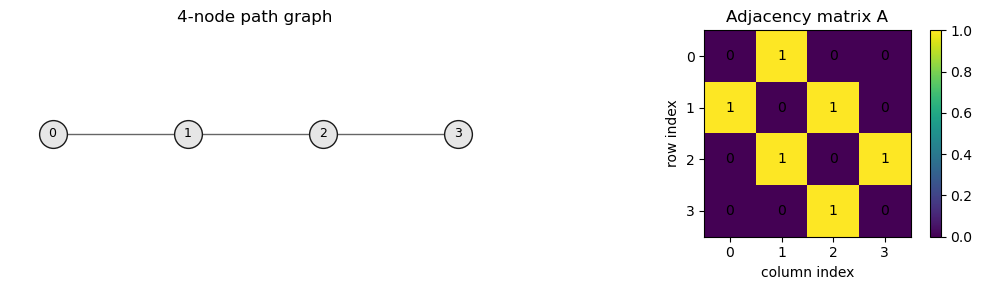

A =
[[0 1 0 0]
 [1 0 1 0]
 [0 1 0 1]
 [0 0 1 0]]

Read it: A[1,2] = 1 means there IS an edge between nodes 1 and 2.
         A[0,3] = 0 means there is NO edge between nodes 0 and 3.


In [9]:
# Build a small graph and its adjacency matrix
G_small = nx.path_graph(4)  # 0 -- 1 -- 2 -- 3
pos_small = {0: (0, 0), 1: (1, 0), 2: (2, 0), 3: (3, 0)}

fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=100)

# Draw the graph
draw_graph(G_small, axes[0], pos=pos_small, title="4-node path graph", node_size=400)

# Show its adjacency matrix
A_small = nx.to_numpy_array(G_small)
plot_matrix_heatmap(A_small, axes[1], title="Adjacency matrix A",
                    ticklabels=[0,1,2,3], annotate=True)

plt.tight_layout()
plt.show()

print("A =")
print(A_small.astype(int))
print()
print("Read it: A[1,2] = 1 means there IS an edge between nodes 1 and 2.")
print("         A[0,3] = 0 means there is NO edge between nodes 0 and 3.")

### But why put the graph in a matrix?

A graph is a picture — edges between nodes. Why rewrite it as a table of 0's and 1's?

**Because matrices let us compute things.** Once the graph is a matrix, we can:
- Multiply it by a vector to aggregate neighbor information
- Raise it to a power to count walks
- Find its eigenvalues to reveal hidden structure
- Apply all the tools of linear algebra

The adjacency matrix is the bridge between the graph (a combinatorial object) and linear algebra (a computational toolkit).

### Key properties of the adjacency matrix

For undirected graphs:
- $A$ is **symmetric**: $A_{ij} = A_{ji}$ (if $i$ connects to $j$, then $j$ connects to $i$).
- The **diagonal is zero**: $A_{ii} = 0$ (no self-loops).
- **Row sums = degrees**: $\sum_j A_{ij} = d_i$ (the degree of node $i$).

Symmetric? True
Diagonal: [0 0 0 0] (all zeros — no self-loops)
Row sums: [1 2 2 1] (these are the node degrees)



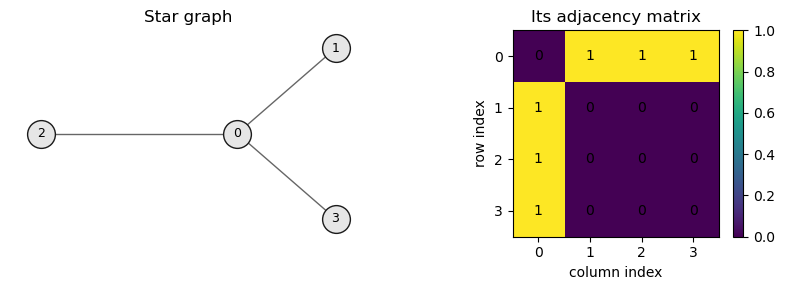

Star degrees: [3 1 1 1]
Node 0 (hub) has degree 3; the others have degree 1.


In [10]:
# Verify these properties
print("Symmetric?", np.allclose(A_small, A_small.T))
print("Diagonal:", np.diag(A_small).astype(int), "(all zeros — no self-loops)")
print("Row sums:", A_small.sum(axis=1).astype(int), "(these are the node degrees)")
print()

# Compare with a different graph
G_star = nx.star_graph(3)  # node 0 connects to 1, 2, 3
A_star = nx.to_numpy_array(G_star)

fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=100)
draw_graph(G_star, axes[0], title="Star graph", node_size=400)
plot_matrix_heatmap(A_star, axes[1], title="Its adjacency matrix",
                    ticklabels=[0,1,2,3], annotate=True)
plt.tight_layout()
plt.show()

print("Star degrees:", A_star.sum(axis=1).astype(int))
print("Node 0 (hub) has degree 3; the others have degree 1.")

## 1.3 Matrix-vector multiplication: the fundamental operation

If there's one operation to understand well, it's this one.

**The rule:** If $A$ is $n \times n$ and $\mathbf{x}$ has $n$ entries, then $\mathbf{y} = A\mathbf{x}$ is a new vector where:

$$y_i = \sum_{j=0}^{n-1} A_{ij}\, x_j = \text{(row } i \text{ of } A) \cdot \mathbf{x}$$

Each output entry is the **dot product** of one row of $A$ with the vector $\mathbf{x}$.

### Ok but what does this *mean* on a graph?

When $A$ is the adjacency matrix, $A_{ij}$ is 1 for neighbors and 0 for everyone else. So:

$$y_i = \sum_{j} A_{ij}\, x_j = \sum_{\text{neighbors } j \text{ of } i} x_j = \textbf{sum of my neighbors' values}$$

Matrix-vector multiplication on a graph is **neighbor aggregation**: each node collects information from its neighbors.

In [11]:
# Concrete example: temperatures on our 4-node path
# Nodes: 0 -- 1 -- 2 -- 3
temps = np.array([50, 70, 80, 60], dtype=float)

# What does A @ temps compute?
neighbor_sums = A_small @ temps

print("Signal (temperatures):", temps)
print("A @ temps (neighbor sums):", neighbor_sums)
print()

# Let's verify by hand:
print("Node 0: neighbors = {1}.       Sum = 70")
print("Node 1: neighbors = {0, 2}.    Sum = 50 + 80 = 130")
print("Node 2: neighbors = {1, 3}.    Sum = 70 + 60 = 130")
print("Node 3: neighbors = {2}.       Sum = 80")

Signal (temperatures): [50. 70. 80. 60.]
A @ temps (neighbor sums): [ 70. 130. 130.  80.]

Node 0: neighbors = {1}.       Sum = 70
Node 1: neighbors = {0, 2}.    Sum = 50 + 80 = 130
Node 2: neighbors = {1, 3}.    Sum = 70 + 60 = 130
Node 3: neighbors = {2}.       Sum = 80


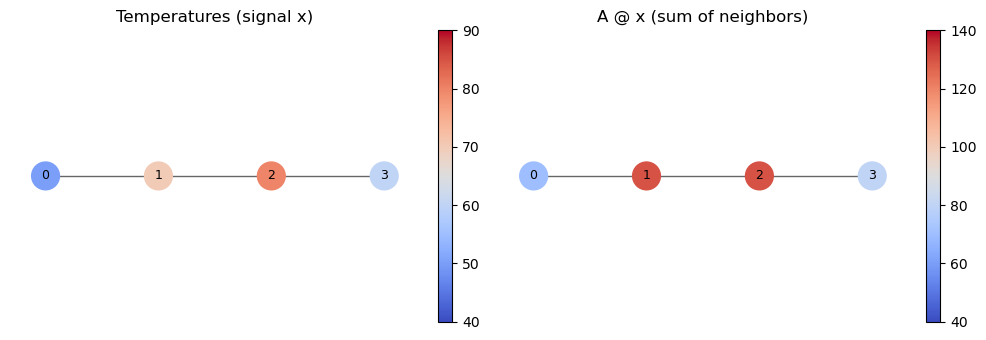

Notice: node 0 (50°) has only one warm neighbor (70°), so its output is low.
Nodes 1 and 2 are in the middle with two neighbors each, so their sums are high.


In [12]:
# Visualize: signal before and after neighbor aggregation
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)

draw_graph(G_small, axes[0], pos=pos_small, values=temps,
           title="Temperatures (signal x)", cmap="coolwarm",
           vmin=40, vmax=90, node_size=400)
draw_graph(G_small, axes[1], pos=pos_small, values=neighbor_sums,
           title="A @ x (sum of neighbors)", cmap="coolwarm",
           vmin=40, vmax=140, node_size=400)

plt.tight_layout()
plt.show()

print("Notice: node 0 (50°) has only one warm neighbor (70°), so its output is low.")
print("Nodes 1 and 2 are in the middle with two neighbors each, so their sums are high.")

### Why does this matter? Two examples.

**Example 1: Averaging.** If instead of summing, we *average* over neighbors (divide by degree), we get a smoothing operation. After one round, extreme values get pulled toward their neighbors. This is how **diffusion** and **consensus** work on networks.

**Example 2: Repeated multiplication.** What if we multiply by $A$ twice? $A^2\mathbf{x}$ sums over *2-hop* neighbors. $A^k\mathbf{x}$ aggregates over $k$-hop neighborhoods. This is how information spreads through a network — and it's why **matrix powers count walks**.

Neighbor sums:     [ 70. 130. 130.  80.]
Degrees:           [1 2 2 1]
Neighbor averages: [70. 65. 65. 80.]

Node 0: avg of neighbors = 70/1 = 70
Node 1: avg of neighbors = (50+80)/2 = 65



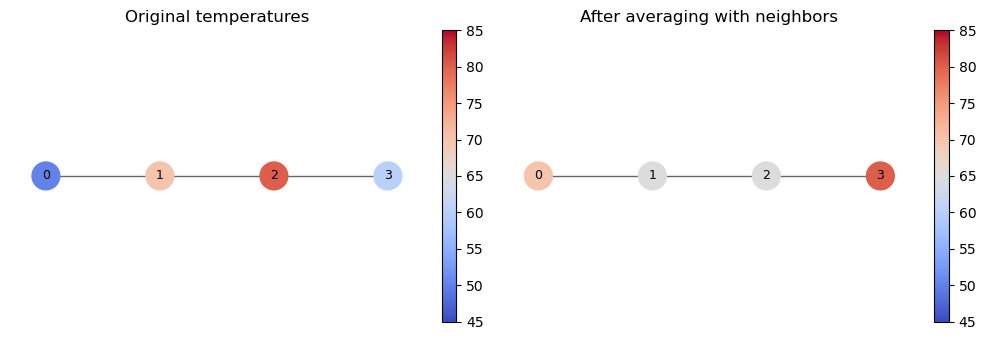

Averaging smooths the signal — extremes get pulled toward the center.


In [13]:
# Averaging over neighbors (divide by degree)
degrees = A_small.sum(axis=1)
D_inv = np.diag(1.0 / degrees)
neighbor_avg = D_inv @ A_small @ temps

print("Neighbor sums:    ", neighbor_sums)
print("Degrees:          ", degrees.astype(int))
print("Neighbor averages:", neighbor_avg)
print()
print("Node 0: avg of neighbors = 70/1 = 70")
print("Node 1: avg of neighbors = (50+80)/2 = 65")
print()

# Visualize: one step of averaging smooths the signal
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)
draw_graph(G_small, axes[0], pos=pos_small, values=temps,
           title="Original temperatures", cmap="coolwarm",
           vmin=45, vmax=85, node_size=400)
draw_graph(G_small, axes[1], pos=pos_small, values=neighbor_avg,
           title="After averaging with neighbors", cmap="coolwarm",
           vmin=45, vmax=85, node_size=400)
plt.tight_layout()
plt.show()
print("Averaging smooths the signal — extremes get pulled toward the center.")

## 1.4 Other matrix operations (quick reference)

A few more operations you'll encounter. Don't memorize — use this as a reference.

**Transpose** $A^\top$: flip rows and columns. $(A^\top)_{ij} = A_{ji}$. Our adjacency matrices are always symmetric ($A = A^\top$) because edges go both ways.

**Identity matrix** $I$: 1's on the diagonal, 0's everywhere else. $I\mathbf{x} = \mathbf{x}$ — it does nothing. Think of it as the "do nothing" matrix.

**Diagonal matrix**: only the diagonal entries are nonzero. The **degree matrix** $D_{ii} = d_i$ is the most important example.

**Matrix-matrix multiplication** $AB$: apply $B$ first, then $A$. This is how we compose operations. For example, $D^{-1}A$ means "first sum neighbors ($A$), then divide by degree ($D^{-1}$)" — this is the neighbor-averaging matrix.

In [14]:
# Key matrices for our 4-node path

# Identity: does nothing
I = np.eye(4)
print("I @ temps =", (I @ temps), "(unchanged)")
print()

# Degree matrix: diagonal with node degrees
D = np.diag(degrees)
print("Degree matrix D:")
print(D.astype(int))
print()

# D @ temps multiplies each node's value by its degree
print("D @ temps =", (D @ temps))
print("(Each temp multiplied by the node's degree)")
print()

# The random walk matrix P = D^{-1} A: neighbor averaging
P = D_inv @ A_small
print("Random walk matrix P = D^{-1}A:")
print(np.round(P, 3))
print()
print("Each row sums to 1 — it's a probability matrix!")
print("Row sums:", P.sum(axis=1))

I @ temps = [50. 70. 80. 60.] (unchanged)

Degree matrix D:
[[1 0 0 0]
 [0 2 0 0]
 [0 0 2 0]
 [0 0 0 1]]

D @ temps = [ 50. 140. 160.  60.]
(Each temp multiplied by the node's degree)

Random walk matrix P = D^{-1}A:
[[0.  1.  0.  0. ]
 [0.5 0.  0.5 0. ]
 [0.  0.5 0.  0.5]
 [0.  0.  1.  0. ]]

Each row sums to 1 — it's a probability matrix!
Row sums: [1. 1. 1. 1.]


## 1.5 The Laplacian: measuring local difference

We now have enough tools to build the **Laplacian matrix**, one of the most important matrices in spectral graph theory.

$$L = D - A$$

Wait, why $D - A$ specifically? Why subtract the adjacency from the degrees?

Think about what $L\mathbf{x}$ computes at each node:

$$(L\mathbf{x})_i = (D\mathbf{x})_i - (A\mathbf{x})_i = d_i \cdot x_i - \sum_{\text{neighbors } j} x_j$$

That's "my value times my degree, minus the sum of my neighbors' values." We can rewrite this as:

$$(L\mathbf{x})_i = \sum_{\text{neighbors } j} (x_i - x_j)$$

The **sum of differences between me and each of my neighbors**. The Laplacian measures **how different a node is from its local neighborhood**.

### Physical intuition

Imagine each edge is a **spring** connecting two nodes. Each node has a "height" given by $x_i$. The Laplacian $L\mathbf{x}$ gives the net **restoring force** on each node — it gets pulled toward the average of its neighbors.

- If node $i$ is higher than all its neighbors: $(L\mathbf{x})_i > 0$ (net force pulling it down).
- If node $i$ equals all its neighbors: $(L\mathbf{x})_i = 0$ (no force, equilibrium).
- If node $i$ is lower than all its neighbors: $(L\mathbf{x})_i < 0$ (net force pulling it up).

This is why the Laplacian is the right matrix for studying **smoothness**, **diffusion**, and **community structure**.

In [15]:
# Build the Laplacian
L_small = D - A_small
print("D ="); print(D.astype(int)); print()
print("A ="); print(A_small.astype(int)); print()
print("L = D - A:"); print(L_small.astype(int)); print()

# Apply L to our temperature signal
Lx = L_small @ temps
print("temps =", temps)
print("L @ temps =", Lx)
print()

# Verify for node 1 (temp=70, neighbors: node 0=50, node 2=80)
# (70-50) + (70-80) = 20 + (-10) = 10
print("Node 1: (70-50) + (70-80) = 20 + (-10) = 10  ✓")
print("  → Node 1 is slightly above its neighbors on average")
print()

# Verify for node 2 (temp=80, neighbors: node 1=70, node 3=60)
# (80-70) + (80-60) = 10 + 20 = 30
print("Node 2: (80-70) + (80-60) = 10 + 20 = 30  ✓")
print("  → Node 2 is well above its neighbors — the 'hot spot'")

D =
[[1 0 0 0]
 [0 2 0 0]
 [0 0 2 0]
 [0 0 0 1]]

A =
[[0 1 0 0]
 [1 0 1 0]
 [0 1 0 1]
 [0 0 1 0]]

L = D - A:
[[ 1 -1  0  0]
 [-1  2 -1  0]
 [ 0 -1  2 -1]
 [ 0  0 -1  1]]

temps = [50. 70. 80. 60.]
L @ temps = [-20.  10.  30. -20.]

Node 1: (70-50) + (70-80) = 20 + (-10) = 10  ✓
  → Node 1 is slightly above its neighbors on average

Node 2: (80-70) + (80-60) = 10 + 20 = 30  ✓
  → Node 2 is well above its neighbors — the 'hot spot'


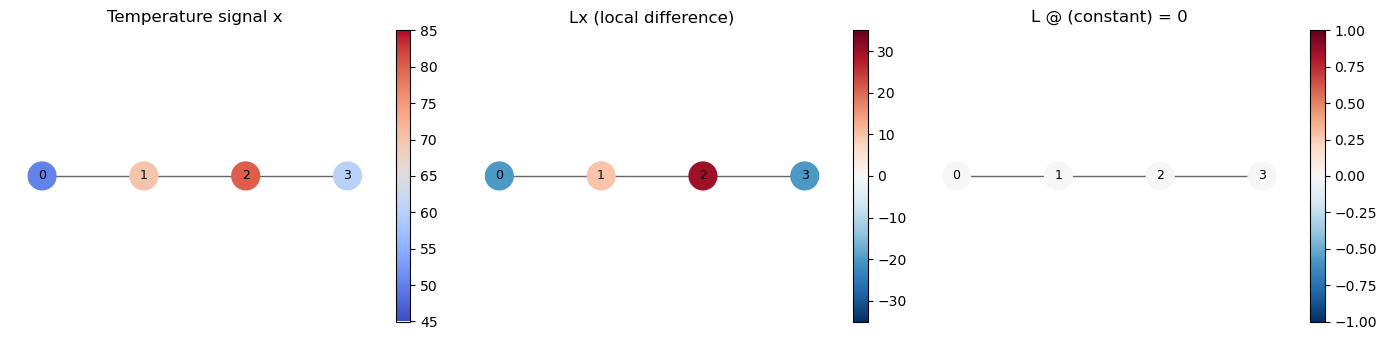

Left: the original signal. Middle: where each node differs from neighbors.
Right: a constant signal has zero Laplacian — no local differences anywhere.


In [16]:
# Visualize: the Laplacian highlights where the signal is locally extreme
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=100)

draw_graph(G_small, axes[0], pos=pos_small, values=temps,
           title="Temperature signal x", cmap="coolwarm",
           vmin=45, vmax=85, node_size=400)
draw_graph(G_small, axes[1], pos=pos_small, values=Lx,
           title="Lx (local difference)", cmap="RdBu_r",
           vmin=-35, vmax=35, node_size=400)

# Now try a constant signal — L should give all zeros
Lx_const = L_small @ np.array([70, 70, 70, 70], dtype=float)
draw_graph(G_small, axes[2], pos=pos_small, values=Lx_const,
           title="L @ (constant) = 0", cmap="RdBu_r",
           vmin=-1, vmax=1, node_size=400)

plt.tight_layout()
plt.show()

print("Left: the original signal. Middle: where each node differs from neighbors.")
print("Right: a constant signal has zero Laplacian — no local differences anywhere.")

### Why $L \cdot \mathbf{1} = \mathbf{0}$?

The constant vector $\mathbf{1} = (1, 1, \ldots, 1)$ always satisfies $L\mathbf{1} = \mathbf{0}$.

Why? Because if every node has the same value, then every neighbor difference is zero:

$$(L\mathbf{1})_i = \sum_{\text{neighbors } j} (1 - 1) = 0$$

The constant signal is **perfectly smooth** — there is zero tension in the springs. This will be important: it means $\mathbf{1}$ is an **eigenvector** of $L$ with eigenvalue 0. It's the "silence" mode — the vibration pattern with zero frequency.

## 1.6 NumPy cheat sheet

| Operation | NumPy | Notes |
|:---|:---|:---|
| Create a vector | `np.array([1, 2, 3])` | |
| Create a matrix | `np.array([[1,2],[3,4]])` | |
| Zeros / ones | `np.zeros(n)`, `np.ones(n)` | |
| Identity matrix | `np.eye(n)` | |
| Diagonal matrix | `np.diag([1,2,3])` | |
| Matrix-vector product | `A @ x` | **Not** `A * x` (that's element-wise!) |
| Matrix-matrix product | `A @ B` | |
| Element-wise multiply | `A * B` | |
| Dot product | `x @ y` | same operator, works for 1D |
| Transpose | `A.T` | |
| Row sums | `A.sum(axis=1)` | = degree vector for adjacency |
| Eigenvalues | `np.linalg.eigh(A)` | for symmetric matrices |
| Norm | `np.linalg.norm(x)` | |
| Shape | `A.shape` | returns (rows, cols) |

**Common mistake:** `A * x` is element-wise multiplication. `A @ x` is matrix-vector multiplication. They give **very different results**.

In [17]:
# The most common NumPy mistake: * vs @
x = np.array([1, 2, 3, 4], dtype=float)

print("A @ x (matrix-vector product):", A_small @ x)
print("A * x (element-wise — WRONG!):")
print(A_small * x)
print()
print("A @ x gives a vector (what we want).")
print("A * x gives a matrix (probably not what we want).")
print("Always use @ for linear algebra operations!")

A @ x (matrix-vector product): [2. 4. 6. 3.]
A * x (element-wise — WRONG!):
[[0. 2. 0. 0.]
 [1. 0. 3. 0.]
 [0. 2. 0. 4.]
 [0. 0. 3. 0.]]

A @ x gives a vector (what we want).
A * x gives a matrix (probably not what we want).
Always use @ for linear algebra operations!


### Your turn!

Predict before running:
1. What is `A @ A` for our 4-node path? (Hint: $(A^2)_{ij}$ counts the number of length-2 walks from $i$ to $j$.)
2. What is the trace (sum of diagonal) of $A^2$? What does it count?
3. What does `L @ np.array([0, 0, 10, 0])` give? (A signal that's nonzero only at node 2.)

In [18]:
# Reference solution
print("=== A^2 ===")
A2_small = A_small @ A_small
print(A2_small.astype(int))
print()
print("A²[0,0] = 1: there is 1 length-2 walk from node 0 back to itself (0→1→0)")
print("A²[0,2] = 1: there is 1 length-2 walk from 0 to 2 (0→1→2)")
print("A²[1,1] = 2: there are 2 length-2 walks from 1 to itself (1→0→1 and 1→2→1)")
print()

print("Trace of A² =", int(np.trace(A2_small)))
print("= 2 × number of edges =", 2 * G_small.number_of_edges())
print("(Each edge contributes two closed walks: i→j→i at both endpoints)")
print()

print("=== L @ spike ===")
spike = np.array([0, 0, 10, 0], dtype=float)
print("L @", spike, "=", L_small @ spike)
print("Node 1: (0 - 10) = -10  (neighbor is higher)")
print("Node 2: (10 - 0) + (10 - 0) = 20  (I'm higher than both neighbors)")
print("Node 3: (0 - 10) = -10  (neighbor is higher)")
print("The Laplacian detects the spike — the node that stands out from its neighbors.")

=== A^2 ===
[[1 0 1 0]
 [0 2 0 1]
 [1 0 2 0]
 [0 1 0 1]]

A²[0,0] = 1: there is 1 length-2 walk from node 0 back to itself (0→1→0)
A²[0,2] = 1: there is 1 length-2 walk from 0 to 2 (0→1→2)
A²[1,1] = 2: there are 2 length-2 walks from 1 to itself (1→0→1 and 1→2→1)

Trace of A² = 6
= 2 × number of edges = 6
(Each edge contributes two closed walks: i→j→i at both endpoints)

=== L @ spike ===
L @ [ 0.  0. 10.  0.] = [  0. -10.  20. -10.]
Node 1: (0 - 10) = -10  (neighbor is higher)
Node 2: (10 - 0) + (10 - 0) = 20  (I'm higher than both neighbors)
Node 3: (0 - 10) = -10  (neighbor is higher)
The Laplacian detects the spike — the node that stands out from its neighbors.


## 1.7 Why symmetry matters (a preview)

All our graph matrices ($A$, $L$, $L_{\text{sym}}$) are **symmetric** for undirected graphs: $M = M^\top$.

Why do we care? Because symmetric matrices have a guarantee that will be the foundation of everything we do:

> **Every $n \times n$ symmetric matrix has exactly $n$ real eigenvalues and $n$ orthogonal eigenvectors.**

This means:
1. The eigenvalues are real numbers (not complex) — we can plot them on a number line.
2. The eigenvectors are perpendicular to each other — they represent *independent* patterns.
3. Together, the eigenvectors form a **complete basis** — *any* signal on the graph can be decomposed into a sum of eigenvector components.

This is the spectral theorem. We'll see it in action in Part 2.

For now, just remember: **symmetry guarantees a clean decomposition into independent modes.** Without it, the eigenvalue story gets much more complicated (complex numbers, non-orthogonal vectors, possible deficiencies). We're lucky that undirected graphs give us symmetric matrices.

---

# Part 2 — What Are Eigenvalues, Really?

We've been building tools: vectors, matrices, multiplication. Now we arrive at the central concept.

Before we apply eigenvalues to networks, let's understand what they **are**, where they **came from**, and why people have cared about them for 200+ years.

## 2.1 The history: why anyone cared in the first place

The word **eigenvalue** comes from the German *Eigenwert* — literally "own value" or "characteristic value." The concept emerged from several different problems in the 1700s and 1800s, all of which turned out to be the same problem in disguise:

### The vibrating string (1700s)

[Daniel Bernoulli](https://en.wikipedia.org/wiki/Daniel_Bernoulli) and [Leonhard Euler](https://en.wikipedia.org/wiki/Leonhard_Euler) studied vibrating strings (like a guitar string). They discovered that a string can only vibrate in certain specific patterns — **modes** — and each mode has its own frequency.

A string pinned at both ends can vibrate as:
- The whole string swinging back and forth (fundamental mode, lowest frequency)
- Two halves swinging in opposite directions (first overtone, double the frequency)
- Three segments (second overtone, triple the frequency)
- And so on...

The frequencies are the **eigenvalues**. The vibration patterns are the **eigenvectors**. Bernoulli and Euler didn't use this language, but they were solving eigenvalue problems.

### Planetary motion (1700s-1800s)

[Joseph-Louis Lagrange](https://en.wikipedia.org/wiki/Joseph-Louis_Lagrange) studied the stability of the solar system. He needed to understand how small perturbations (tiny gravitational tugs between planets) would evolve over time. This led him to study the "characteristic values" of matrices describing the coupled oscillations — eigenvalues.

If all eigenvalues are small, the perturbations stay small (stable orbits). If any eigenvalue is large, tiny disturbances grow (unstable orbits). **Eigenvalues tell you about the long-term behavior of dynamical systems.**

### Rotation and inertia (1800s)

[Augustin-Louis Cauchy](https://en.wikipedia.org/wiki/Augustin-Louis_Cauchy) formalized eigenvalues in the context of rigid body rotation. If you spin a 3D object, most directions wobble. But there are special axes — the **principal axes** — around which the object spins cleanly without wobbling. These are the eigenvectors of the **inertia tensor** (a 3×3 matrix). The eigenvalues give the moments of inertia.

### The common thread

In every case, the pattern is the same:

> **A physical system has a linear operator (matrix) that describes its behavior. The eigenvalues and eigenvectors of that operator reveal the system's natural modes — the patterns that sustain themselves over time.**

This is why eigenvalues are everywhere: they're not a quirk of linear algebra. They're the mathematical language for describing **what a system naturally does**.

## 2.2 The definition

Let $M$ be an $n \times n$ matrix. A nonzero vector $\mathbf{v}$ is an **eigenvector** of $M$ with **eigenvalue** $\lambda$ if:

$$\boxed{M\mathbf{v} = \lambda \mathbf{v}}$$

Read this carefully. The left side, $M\mathbf{v}$, is a matrix times a vector — a complicated operation that could send $\mathbf{v}$ anywhere. The right side, $\lambda \mathbf{v}$, is just the *same vector* scaled by a number. The equation says: **for this particular vector, the complicated matrix multiplication happens to be equivalent to simple scalar multiplication.**

Most vectors don't satisfy this. For a random vector $\mathbf{x}$, $M\mathbf{x}$ will point in a completely different direction from $\mathbf{x}$. Eigenvectors are the rare, special directions where the matrix's action is simple.

There are a few different ways to think about what this equation means. Let's walk through them.

### "It keeps its direction"

When you multiply a matrix by a generic vector, the output points somewhere new. The vector gets rotated, stretched, sheared — its shape changes unpredictably.

An eigenvector is different. After multiplication, **it still points in the same direction.** The matrix might stretch it ($\lambda > 1$), shrink it ($0 < \lambda < 1$), flip it to the opposite direction ($\lambda < 0$), or collapse it to zero ($\lambda = 0$). But the *line* it lies along doesn't change.

Think about what that means concretely. Say you have a 2D matrix and two vectors:

- A **generic** vector $\mathbf{x} = (1, 0.3)$: after multiplying by $M$, it might become $(2.3, 1.6)$ — totally different direction.
- An **eigenvector** $\mathbf{v} = (0.71, 0.71)$: after multiplying by $M$, it becomes $(2.13, 2.13)$ — same direction, just 3× longer.

The eigenvector "survives" the matrix.

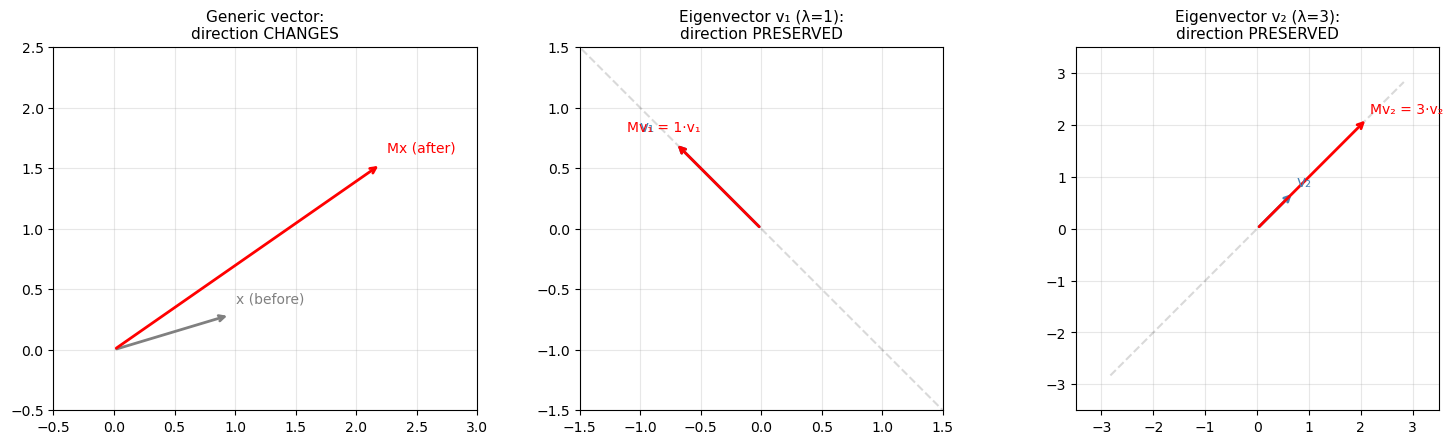

Matrix M = [[2, 1], [1, 2]]
Eigenvalues: λ₁ = 1, λ₂ = 3
v₁ = [-0.707  0.707]  →  Mv₁ = [-0.707  0.707]  =  1 × v₁
v₂ = [0.707 0.707]  →  Mv₂ = [2.121 2.121]  =  3 × v₂


In [19]:
# Interpretation 1: eigenvectors keep their direction

M = np.array([[2, 1],
              [1, 2]], dtype=float)

# Find the eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(M)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=100)

# Panel 1: a generic vector — direction CHANGES
ax = axes[0]
x = np.array([1, 0.3])
x = x / np.linalg.norm(x)
Mx = M @ x
ax.annotate('', xy=x, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='gray', lw=2))
ax.annotate('', xy=Mx, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(x[0]+0.05, x[1]+0.1, 'x (before)', fontsize=10, color='gray')
ax.text(Mx[0]+0.05, Mx[1]+0.1, 'Mx (after)', fontsize=10, color='red')
# Show the angle changed
ax.set_xlim(-0.5, 3); ax.set_ylim(-0.5, 2.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Generic vector:\ndirection CHANGES', fontsize=11)

# Panel 2: eigenvector 1 — direction PRESERVED
ax = axes[1]
v1 = eigenvectors[:, 0]
Mv1 = M @ v1
ax.annotate('', xy=v1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.annotate('', xy=Mv1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(v1[0]-0.3, v1[1]+0.1, f'v₁', fontsize=11, color='steelblue')
ax.text(Mv1[0]-0.4, Mv1[1]+0.1, f'Mv₁ = {eigenvalues[0]:.0f}·v₁', fontsize=10, color='red')
# Draw the line through origin showing direction is preserved
t = np.linspace(-3, 3, 100)
ax.plot(t * v1[0], t * v1[1], 'k--', alpha=0.15)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title(f'Eigenvector v₁ (λ={eigenvalues[0]:.0f}):\ndirection PRESERVED', fontsize=11)

# Panel 3: eigenvector 2 — direction PRESERVED
ax = axes[2]
v2 = eigenvectors[:, 1]
Mv2 = M @ v2
ax.annotate('', xy=v2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.annotate('', xy=Mv2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(v2[0]+0.05, v2[1]+0.1, f'v₂', fontsize=11, color='steelblue')
ax.text(Mv2[0]+0.05, Mv2[1]+0.1, f'Mv₂ = {eigenvalues[1]:.0f}·v₂', fontsize=10, color='red')
t = np.linspace(-4, 4, 100)
ax.plot(t * v2[0], t * v2[1], 'k--', alpha=0.15)
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title(f'Eigenvector v₂ (λ={eigenvalues[1]:.0f}):\ndirection PRESERVED', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Matrix M = [[2, 1], [1, 2]]")
print(f"Eigenvalues: λ₁ = {eigenvalues[0]:.0f}, λ₂ = {eigenvalues[1]:.0f}")
print(f"v₁ = {np.round(eigenvectors[:,0], 3)}  →  Mv₁ = {np.round(M @ eigenvectors[:,0], 3)}  =  {eigenvalues[0]:.0f} × v₁")
print(f"v₂ = {np.round(eigenvectors[:,1], 3)}  →  Mv₂ = {np.round(M @ eigenvectors[:,1], 3)}  =  {eigenvalues[1]:.0f} × v₂")

### A self-sustaining vibration

Here's another angle. Imagine a physical system that evolves in discrete time steps. At each step, the state gets transformed by a matrix $M$:

$$\mathbf{x}_{t+1} = M \, \mathbf{x}_t$$

Most initial states evolve into something unrecognizable after a few steps — the pattern keeps morphing. But if you start in an eigenvector $\mathbf{v}$:

$$\mathbf{v} \to \lambda\mathbf{v} \to \lambda^2\mathbf{v} \to \lambda^3\mathbf{v} \to \cdots$$

The *shape* never changes. It just gets scaled by $\lambda$ at each step. A standing wave — a pattern that reproduces itself.

- If $|\lambda| > 1$: the pattern grows (unstable vibration)
- If $|\lambda| < 1$: the pattern decays (damped vibration)
- If $|\lambda| = 1$: the pattern sustains forever (pure oscillation)
- If $\lambda < 0$: the pattern flips sign each step (alternating vibration)

This is why eigenvalues show up in every area of science that studies **dynamics** — anything evolving over time. The eigenvalues tell you which patterns grow, which decay, and which persist.

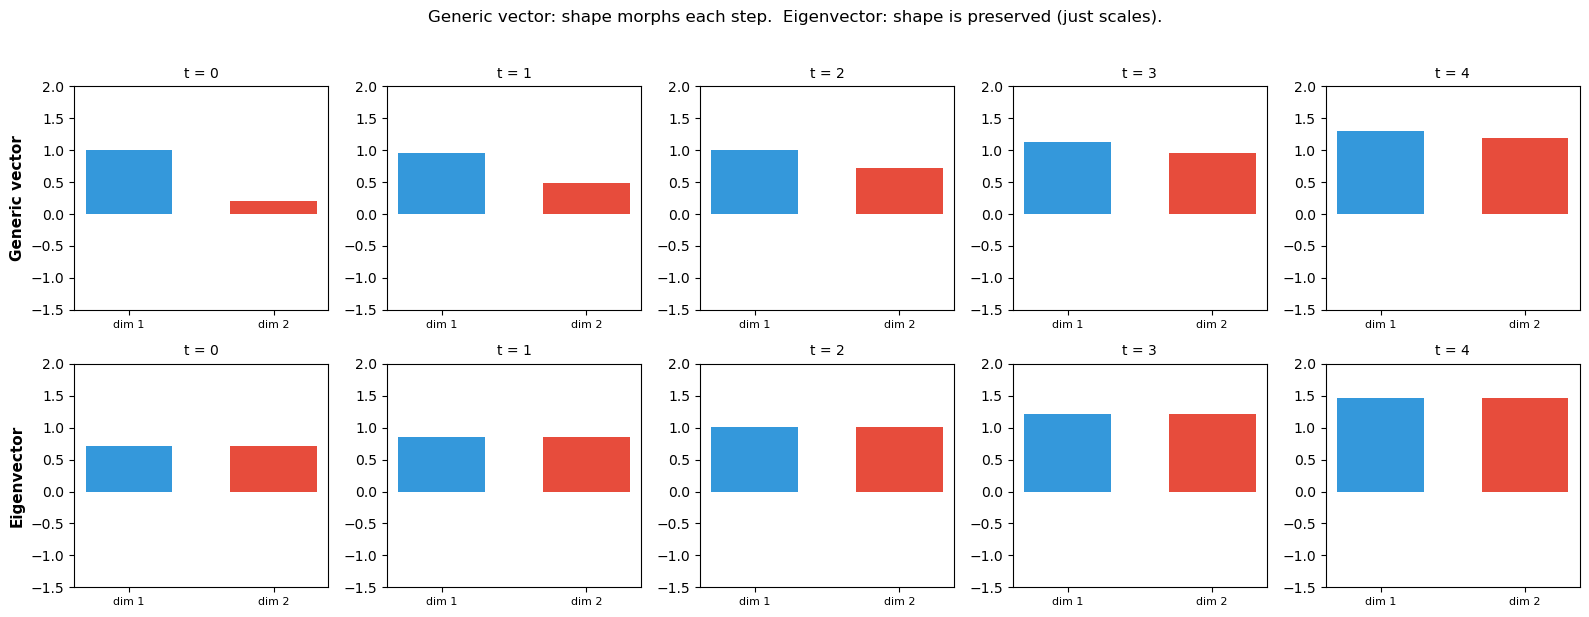

Eigenvalues of M: [0.6 1.2]
The eigenvector with λ = 1.20 grows by 120% each step (> 1 means growing).
The eigenvector with λ = 0.60 shrinks by 40% each step (< 1 means decaying).


In [20]:
# Interpretation 2: eigenvectors as self-sustaining patterns through time
# Start with an eigenvector vs a generic vector and evolve both

M = np.array([[0.9, 0.3],
              [0.3, 0.9]], dtype=float)

vals, vecs = np.linalg.eigh(M)

fig, axes = plt.subplots(2, 5, figsize=(16, 6), dpi=100)

# Top row: generic vector evolves — shape changes each step
x = np.array([1.0, 0.2])
for t in range(5):
    ax = axes[0, t]
    ax.bar([0, 1], x, color=['#3498db', '#e74c3c'], width=0.6)
    ax.set_ylim(-1.5, 2.0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['dim 1', 'dim 2'], fontsize=8)
    ax.set_title(f't = {t}', fontsize=10)
    if t == 0:
        ax.set_ylabel('Generic vector', fontsize=11, fontweight='bold')
    x = M @ x

# Bottom row: eigenvector evolves — shape stays the same, just scales
x = vecs[:, 1].copy() * 1.0  # start at eigenvector
for t in range(5):
    ax = axes[1, t]
    ax.bar([0, 1], x, color=['#3498db', '#e74c3c'], width=0.6)
    ax.set_ylim(-1.5, 2.0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['dim 1', 'dim 2'], fontsize=8)
    ax.set_title(f't = {t}', fontsize=10)
    if t == 0:
        ax.set_ylabel('Eigenvector', fontsize=11, fontweight='bold')
    x = M @ x

plt.suptitle('Generic vector: shape morphs each step.  Eigenvector: shape is preserved (just scales).',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"Eigenvalues of M: {np.round(vals, 3)}")
print(f"The eigenvector with λ = {vals[1]:.2f} grows by {vals[1]:.0%} each step (> 1 means growing).")
print(f"The eigenvector with λ = {vals[0]:.2f} shrinks by {1-vals[0]:.0%} each step (< 1 means decaying).")

### The directions where everything becomes simple

And maybe the deepest way to see it. An $n \times n$ matrix is a complicated object. It has $n^2$ entries, and multiplying it by a vector mixes all $n$ components together. Hard to see what's going on.

But along an eigenvector, this complexity vanishes. The matrix reduces to a single number: the eigenvalue. A 100×100 matrix with 10,000 entries, acting on an eigenvector, behaves like the number $\lambda$.

If you can find **all** $n$ eigenvectors, then you can decompose any vector into eigenvector components, and the matrix acts on each component independently. You've turned one hard problem (multiplying by a big matrix) into $n$ easy problems (multiplying by a number).

In a way, eigenvalues are like little compasses that find the directions where a complex system is most easily understood and described. That's what makes them useful for data analysis — and for basically everything else.

In [21]:
# Interpretation 3: eigenvalues simplify matrix powers
# Without eigenvectors: computing M^k requires k matrix multiplications
# With eigenvectors: M^k just raises each eigenvalue to the k-th power

M = np.array([[2, 1],
              [1, 2]], dtype=float)
vals, vecs = np.linalg.eigh(M)

print("M ="); print(M); print()
print(f"Eigenvalues: λ₁ = {vals[0]:.0f}, λ₂ = {vals[1]:.0f}")
print(f"Eigenvectors: v₁ = {np.round(vecs[:,0], 3)}, v₂ = {np.round(vecs[:,1], 3)}")
print()

# Compute M^10 two ways
k = 10

# Way 1: brute force
M_k_brute = np.linalg.matrix_power(M, k)

# Way 2: using eigenvalues — just raise each eigenvalue to the k-th power
# M^k = V @ diag(λ^k) @ V^T
M_k_eigen = vecs @ np.diag(vals**k) @ vecs.T

print(f"M^{k} (brute force, {k} matrix multiplications):")
print(np.round(M_k_brute, 1))
print()
print(f"M^{k} (via eigenvalues: λ₁^{k} = {vals[0]**k:.0f}, λ₂^{k} = {vals[1]**k:.0f}):")
print(np.round(M_k_eigen, 1))
print()
print(f"Same? {np.allclose(M_k_brute, M_k_eigen)}")
print()
print(f"The eigenvalue decomposition turns 'multiply by a matrix {k} times'")
print(f"into 'raise two numbers to the {k}th power.' That's the simplification.")

M =
[[2. 1.]
 [1. 2.]]

Eigenvalues: λ₁ = 1, λ₂ = 3
Eigenvectors: v₁ = [-0.707  0.707], v₂ = [0.707 0.707]

M^10 (brute force, 10 matrix multiplications):
[[29525. 29524.]
 [29524. 29525.]]

M^10 (via eigenvalues: λ₁^10 = 1, λ₂^10 = 59049):
[[29525. 29524.]
 [29524. 29525.]]

Same? True

The eigenvalue decomposition turns 'multiply by a matrix 10 times'
into 'raise two numbers to the 10th power.' That's the simplification.


## 2.2b How do we actually *find* eigenvalues?

Ok so eigenvectors satisfy $M\mathbf{v} = \lambda\mathbf{v}$. But how do you find them? You can't just try every possible vector.

### Rearranging the equation

Start with $M\mathbf{v} = \lambda\mathbf{v}$ and rearrange:

$$M\mathbf{v} - \lambda\mathbf{v} = \mathbf{0}$$

$$(M - \lambda I)\mathbf{v} = \mathbf{0}$$

(We need the identity matrix $I$ because you can't subtract a number from a matrix directly.)

Now think about what this says: we need a **nonzero** vector $\mathbf{v}$ that the matrix $(M - \lambda I)$ sends to zero. When does a matrix send nonzero vectors to zero? Only when the matrix is **singular** — when it squishes space down and loses a dimension.

A matrix is singular exactly when its **determinant is zero**:

$$\det(M - \lambda I) = 0$$

This is the **characteristic equation**. It's a polynomial in $\lambda$ of degree $n$, so it has exactly $n$ roots (counting multiplicity). Those roots are the eigenvalues.

### What's happening geometrically?

1. For each candidate value $\lambda$, build the matrix $(M - \lambda I)$
2. Most values of $\lambda$ give an invertible matrix — it doesn't squish anything to zero
3. But at special values of $\lambda$ (the eigenvalues), $(M - \lambda I)$ becomes singular — it collapses certain directions to zero
4. The directions that get collapsed are the eigenvectors

So finding eigenvalues is asking: **"For what values of $\lambda$ does the matrix $M - \lambda I$ lose a dimension?"** And the eigenvectors are the directions that get lost.

M =
[[3. 1.]
 [1. 2.]]



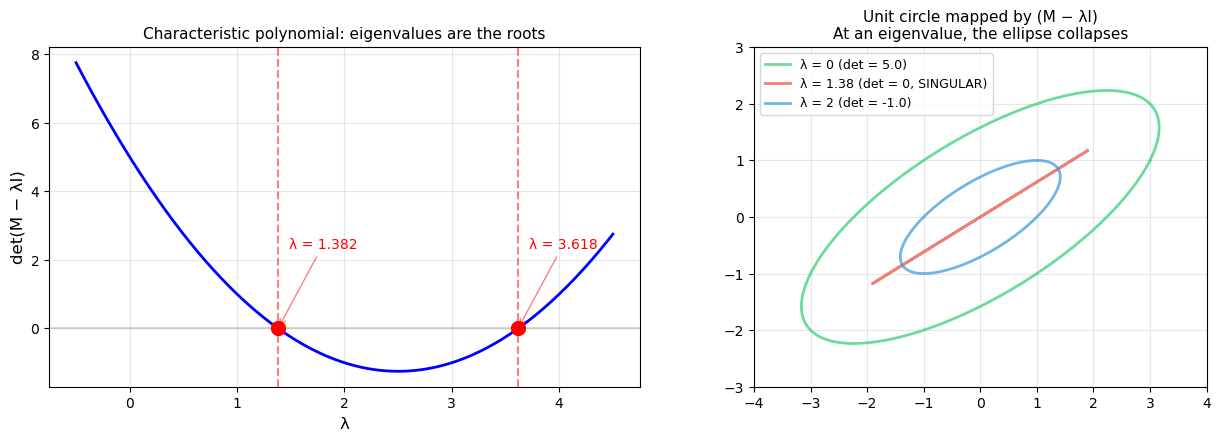

At an eigenvalue, det(M - λI) = 0, meaning (M - λI) is singular.
The ellipse collapses to a LINE — it loses a dimension.
The direction of that line is the eigenvector.


In [22]:
# How eigenvalue computation works: the characteristic equation

M = np.array([[3, 1],
              [1, 2]], dtype=float)

print("M ="); print(M); print()

# For different values of lambda, compute det(M - lambda*I)
lambdas = np.linspace(-0.5, 4.5, 200)
dets = [np.linalg.det(M - lam * np.eye(2)) for lam in lambdas]

# The actual eigenvalues
actual_vals = np.linalg.eigvalsh(M)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)

# Left: the characteristic polynomial
ax = axes[0]
ax.plot(lambdas, dets, 'b-', linewidth=2)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
for val in actual_vals:
    ax.axvline(x=val, color='red', linestyle='--', alpha=0.5)
    ax.plot(val, 0, 'ro', markersize=10, zorder=5)
    ax.annotate(f'λ = {val:.3f}', xy=(val, 0), xytext=(val+0.1, max(dets)*0.3),
                fontsize=10, color='red',
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))
ax.set_xlabel('λ', fontsize=12)
ax.set_ylabel('det(M − λI)', fontsize=12)
ax.set_title('Characteristic polynomial: eigenvalues are the roots', fontsize=11)
ax.grid(alpha=0.3)

# Right: show what M - λI looks like at an eigenvalue vs not
ax = axes[1]
# At a non-eigenvalue: M - 0*I = M, invertible
# Draw unit circle and its image under (M - λI) for different λ
theta = np.linspace(0, 2*np.pi, 100)
circle = np.vstack([np.cos(theta), np.sin(theta)])

colors = ['#2ecc71', '#e74c3c', '#3498db']
labels_list = [f'λ = 0 (det = {np.linalg.det(M):.1f})',
          f'λ = {actual_vals[0]:.2f} (det = 0, SINGULAR)',
          f'λ = 2 (det = {np.linalg.det(M - 2*np.eye(2)):.1f})']

for idx, (lam, color, label) in enumerate(zip([0, actual_vals[0], 2], colors, labels_list)):
    B = M - lam * np.eye(2)
    img = B @ circle
    ax.plot(img[0], img[1], color=color, linewidth=2, alpha=0.7, label=label)

ax.set_aspect('equal')
ax.set_title('Unit circle mapped by (M − λI)\nAt an eigenvalue, the ellipse collapses', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(-4, 4); ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("At an eigenvalue, det(M - λI) = 0, meaning (M - λI) is singular.")
print("The ellipse collapses to a LINE — it loses a dimension.")
print("The direction of that line is the eigenvector.")

## 2.2c The eigenvalue-eigenvector connection

Eigenvalues and eigenvectors always come in pairs. You never have one without the other. So how should we think about their relationship?

### They answer different questions about the same thing

| | Eigenvector $\mathbf{v}$ | Eigenvalue $\lambda$ |
|:---|:---|:---|
| **What it tells you** | *Which* direction / *which* pattern | *How much* scaling / *how fast* |
| **Musical note analogy** | The waveform shape (what instrument?) | The pitch and volume |
| **River analogy** | The direction of the current | The speed of the current |
| **In data (PCA)** | Which combination of variables | How much variance it explains |
| **On a graph** | Which nodes participate, and how | How rough/smooth the pattern is |
| **In dynamics** | Which mode of behavior | Growth rate of that mode |

The eigenvector says **what**. The eigenvalue says **how much**.

### They constrain each other

Given a matrix $M$, you can't choose eigenvectors and eigenvalues independently. Once you fix one, the other is determined:

- If you know $\mathbf{v}$ is an eigenvector, the eigenvalue must be $\lambda = \frac{\mathbf{v}^\top M \mathbf{v}}{\mathbf{v}^\top \mathbf{v}}$ (the **Rayleigh quotient**).
- If you know $\lambda$ is an eigenvalue, the eigenvector must satisfy $(M - \lambda I)\mathbf{v} = 0$ — it's in the **nullspace** of $M - \lambda I$.

Two sides of the same coin.

### Ordering matters

For symmetric matrices, the eigenvalues come in a natural order: $\lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n$. Each eigenvector gets paired with its eigenvalue, and this ordering is meaningful:

- **Smallest eigenvalue → smoothest pattern** (for the Laplacian, this is the constant vector)
- **Largest eigenvalue → roughest pattern** (maximum neighbor disagreement)
- **Middle eigenvalues → patterns of intermediate complexity**

The eigenvalue is literally measuring a property of its eigenvector. For the Laplacian, it measures roughness. For the covariance matrix, it measures variance. The eigenvector is the pattern; the eigenvalue is the measurement of that pattern.

Eigenvalues from np.linalg.eigh: [1.382 3.618]

v1 = [ 0.5257 -0.8507]
  Rayleigh quotient v^T M v / v^T v = 1.3820
  Eigenvalue from eigh:              = 1.3820

v2 = [-0.8507 -0.5257]
  Rayleigh quotient v^T M v / v^T v = 3.6180
  Eigenvalue from eigh:              = 3.6180

For a non-eigenvector x = [1. 0.]:
  Rayleigh quotient = 3.0000
  This lies between λ_min = 1.3820 and λ_max = 3.6180
  (The Rayleigh quotient of any unit vector is always between the smallest and largest eigenvalue.)



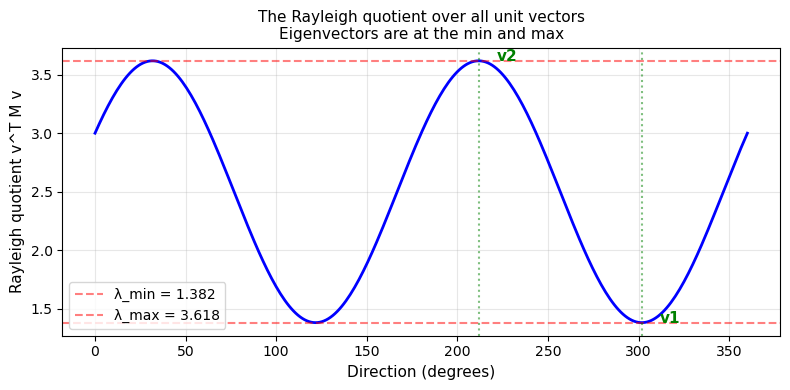

The Rayleigh quotient sweeps between λ_min and λ_max.
It reaches its minimum AT the first eigenvector and its maximum AT the last.
Eigenvectors are the extreme directions of the matrix's action.


In [23]:
# The eigenvalue-eigenvector connection: the Rayleigh quotient
# The eigenvalue of an eigenvector v is: λ = (v^T M v) / (v^T v)

M = np.array([[3, 1],
              [1, 2]], dtype=float)
vals, vecs = np.linalg.eigh(M)

print("Eigenvalues from np.linalg.eigh:", np.round(vals, 4))
print()

# Verify: Rayleigh quotient recovers the eigenvalue
for i in range(2):
    v = vecs[:, i]
    rayleigh = (v @ M @ v) / (v @ v)
    print(f"v{i+1} = {np.round(v, 4)}")
    print(f"  Rayleigh quotient v^T M v / v^T v = {rayleigh:.4f}")
    print(f"  Eigenvalue from eigh:              = {vals[i]:.4f}")
    print()

# What happens for a NON-eigenvector?
x = np.array([1, 0], dtype=float)  # not an eigenvector
rayleigh_x = (x @ M @ x) / (x @ x)
print(f"For a non-eigenvector x = {x}:")
print(f"  Rayleigh quotient = {rayleigh_x:.4f}")
print(f"  This lies between λ_min = {vals[0]:.4f} and λ_max = {vals[1]:.4f}")
print(f"  (The Rayleigh quotient of any unit vector is always between the smallest and largest eigenvalue.)")
print()

# Visualize: Rayleigh quotient as a function of angle
theta = np.linspace(0, 2*np.pi, 300)
rayleigh_vals = []
for t in theta:
    v = np.array([np.cos(t), np.sin(t)])
    rayleigh_vals.append(v @ M @ v)

fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=100)
ax.plot(np.degrees(theta), rayleigh_vals, 'b-', linewidth=2)
ax.axhline(y=vals[0], color='red', linestyle='--', alpha=0.5, label=f'λ_min = {vals[0]:.3f}')
ax.axhline(y=vals[1], color='red', linestyle='--', alpha=0.5, label=f'λ_max = {vals[1]:.3f}')

# Mark where the eigenvectors are
for i in range(2):
    angle = np.degrees(np.arctan2(vecs[1,i], vecs[0,i])) % 360
    ax.axvline(x=angle, color='green', linestyle=':', alpha=0.5)
    ax.annotate(f'v{i+1}', xy=(angle, vals[i]), fontsize=11, color='green',
                xytext=(angle+10, vals[i]), fontweight='bold')

ax.set_xlabel('Direction (degrees)', fontsize=11)
ax.set_ylabel('Rayleigh quotient v^T M v', fontsize=11)
ax.set_title('The Rayleigh quotient over all unit vectors\nEigenvectors are at the min and max', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("The Rayleigh quotient sweeps between λ_min and λ_max.")
print("It reaches its minimum AT the first eigenvector and its maximum AT the last.")
print("Eigenvectors are the extreme directions of the matrix's action.")

## 2.3 Seeing it: the circle-to-ellipse picture

There's a really nice geometric way to visualize what a matrix does, and it makes eigenvectors obvious. Let's build it up step by step.

### Step 1: Start with a circle of vectors

Take every unit vector in 2D — all the vectors of length 1. Together they form the **unit circle**. Each point on the circle is a direction you could point.

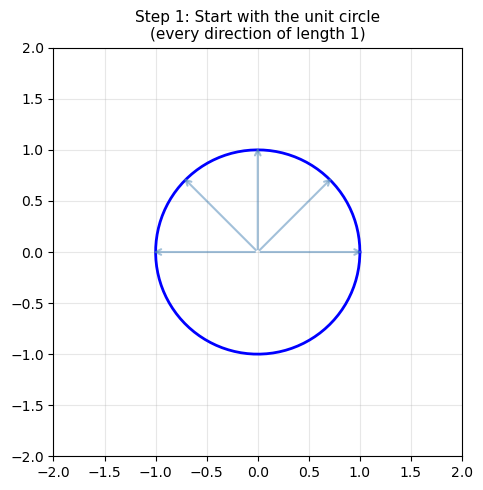

Every point on this circle is a unit vector — a direction.
Now let's see what the matrix M does to ALL of these directions at once.


In [24]:
# Step 1: the unit circle — all directions
M = np.array([[2, 1],
              [1, 3]], dtype=float)

theta = np.linspace(0, 2 * np.pi, 200)
circle = np.vstack([np.cos(theta), np.sin(theta)])

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=100)
ax.plot(circle[0], circle[1], 'b-', linewidth=2, label='Unit circle')

# Mark a few specific vectors
for angle, label in [(0, 'x'), (np.pi/4, ''), (np.pi/2, 'y'), (np.pi, ''), (3*np.pi/4, '')]:
    v = np.array([np.cos(angle), np.sin(angle)])
    ax.annotate('', xy=v*1.05, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5, alpha=0.5))

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Step 1: Start with the unit circle\n(every direction of length 1)', fontsize=11)
plt.tight_layout()
plt.show()

print("Every point on this circle is a unit vector — a direction.")
print("Now let's see what the matrix M does to ALL of these directions at once.")

### Step 2: Apply the matrix — the circle becomes an ellipse

Now multiply every vector on the circle by the matrix $M$. Each unit vector $\mathbf{u}$ gets mapped to $M\mathbf{u}$. What shape do we get?

For a symmetric matrix, the circle always maps to an **ellipse**. Some directions get stretched more than others. The circle gets distorted, but it stays smooth — no sharp corners or folds.

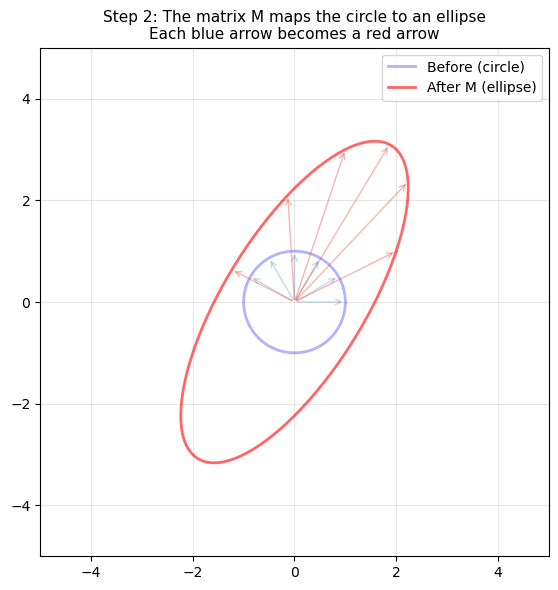

Notice: most vectors change BOTH their length AND their direction.
The blue arrows and red arrows point in different directions.
But are there any directions where the arrow doesn't rotate?


In [25]:
# Step 2: M maps the circle to an ellipse
ellipse = M @ circle

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.plot(circle[0], circle[1], 'b-', linewidth=2, alpha=0.3, label='Before (circle)')
ax.plot(ellipse[0], ellipse[1], 'r-', linewidth=2, alpha=0.6, label='After M (ellipse)')

# Draw arrows showing a few vectors before → after
for angle in [0, np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3, 5*np.pi/6]:
    v = np.array([np.cos(angle), np.sin(angle)])
    Mv = M @ v
    ax.annotate('', xy=v, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1, alpha=0.3))
    ax.annotate('', xy=Mv, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1, alpha=0.4))

ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(fontsize=10)
ax.set_title('Step 2: The matrix M maps the circle to an ellipse\nEach blue arrow becomes a red arrow', fontsize=11)
plt.tight_layout()
plt.show()

print("Notice: most vectors change BOTH their length AND their direction.")
print("The blue arrows and red arrows point in different directions.")
print("But are there any directions where the arrow doesn't rotate?")

### Step 3: Find the special directions — the eigenvectors

Look at the ellipse. It has two axes: a **long axis** (the direction of maximum stretching) and a **short axis** (the direction of minimum stretching). These axes are perpendicular.

Along these axes — and *only* along these axes — the matrix stretches the vector **without rotating it**. A vector pointing along the long axis goes in, and a longer vector pointing in the *same direction* comes out. Same for the short axis.

These are the **eigenvectors**. The amount of stretching along each axis is the **eigenvalue**.

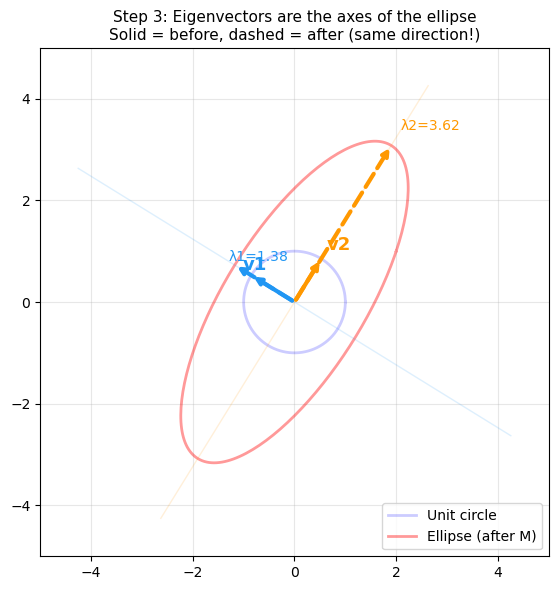

Eigenvector v₁ = [-0.851  0.526] with eigenvalue λ₁ = 1.382 (short axis)
Eigenvector v₂ = [0.526 0.851] with eigenvalue λ₂ = 3.618 (long axis)

v₁ gets stretched by λ₁ ≈ 1.4×. v₂ gets stretched by λ₂ ≈ 3.6×.
These are the ONLY directions where M stretches without rotating.


In [26]:
# Step 3: The eigenvectors are the axes of the ellipse
vals_2d, vecs_2d = np.linalg.eigh(M)

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
ax.plot(circle[0], circle[1], 'b-', linewidth=2, alpha=0.2, label='Unit circle')
ax.plot(ellipse[0], ellipse[1], 'r-', linewidth=2, alpha=0.4, label='Ellipse (after M)')

colors = ['#2196F3', '#FF9800']
labels = ['Short axis', 'Long axis']

for i in range(2):
    v = vecs_2d[:, i]
    lam = vals_2d[i]

    # Eigenvector on the circle (before)
    ax.annotate('', xy=v, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))

    # Where it lands on the ellipse (after) — same direction, scaled by λ
    ax.annotate('', xy=lam * v, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3, linestyle='--'))

    # Draw the full axis line
    t = np.linspace(-5, 5, 100)
    ax.plot(t * v[0], t * v[1], color=colors[i], alpha=0.15, linewidth=1)

    ax.text(v[0]*1.2, v[1]*1.2, f'v{i+1}', fontsize=13, color=colors[i], fontweight='bold')
    ax.text(lam*v[0]*1.1, lam*v[1]*1.1, f'λ{i+1}={lam:.2f}',
            fontsize=10, color=colors[i])

ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(fontsize=10, loc='lower right')
ax.set_title('Step 3: Eigenvectors are the axes of the ellipse\nSolid = before, dashed = after (same direction!)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Eigenvector v₁ = {np.round(vecs_2d[:,0], 3)} with eigenvalue λ₁ = {vals_2d[0]:.3f} (short axis)")
print(f"Eigenvector v₂ = {np.round(vecs_2d[:,1], 3)} with eigenvalue λ₂ = {vals_2d[1]:.3f} (long axis)")
print()
print("v₁ gets stretched by λ₁ ≈ {:.1f}×. v₂ gets stretched by λ₂ ≈ {:.1f}×.".format(vals_2d[0], vals_2d[1]))
print("These are the ONLY directions where M stretches without rotating.")

### Step 4: What about every other direction?

Every vector that is NOT an eigenvector gets **both** stretched and rotated. The closer a vector is to the dominant eigenvector (the long axis), the less it rotates. The farther away, the more dramatic the rotation.

This is why the dominant eigenvector is so important: it's the direction the matrix "pulls everything toward." After many repeated multiplications, all vectors converge toward it (this is power iteration, which we'll see later).

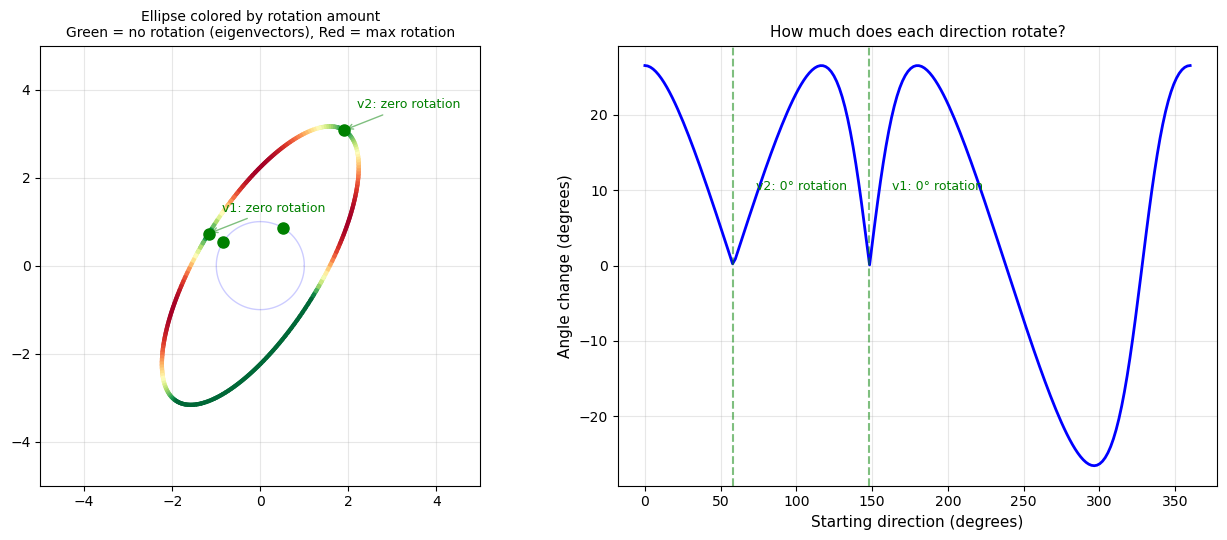

Eigenvectors are the directions with ZERO rotation.
All other directions get rotated by some amount.
The eigenvectors are geometrically special — they're the 'grain' of the matrix.


In [27]:
# Step 4: Show what happens to ALL directions
# Color each vector by how much its angle changes

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), dpi=100)

# Left: colored by angle change
ax = axes[0]
angles_before = theta
angles_after = np.arctan2(ellipse[1], ellipse[0])
angle_change = np.abs(angles_after - angles_before)
# Normalize to [0, pi]
angle_change = np.minimum(angle_change, 2*np.pi - angle_change)

# Plot ellipse colored by rotation amount
for j in range(len(theta)-1):
    color_val = angle_change[j] / angle_change.max()
    c = plt.cm.RdYlGn_r(color_val)  # green = no rotation, red = lots
    ax.plot(ellipse[0, j:j+2], ellipse[1, j:j+2], color=c, linewidth=3)

ax.plot(circle[0], circle[1], 'b-', linewidth=1, alpha=0.2)

# Mark eigenvectors (zero rotation)
for i in range(2):
    v = vecs_2d[:, i]
    lam = vals_2d[i]
    ax.plot(*v, 'go', markersize=8, zorder=5)
    ax.plot(*(lam*v), 'go', markersize=8, zorder=5)
    ax.annotate(f'v{i+1}: zero rotation', xy=(lam*v[0], lam*v[1]),
                xytext=(lam*v[0]+0.3, lam*v[1]+0.5),
                fontsize=9, color='green',
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.5))

ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.set_title('Ellipse colored by rotation amount\nGreen = no rotation (eigenvectors), Red = max rotation', fontsize=10)

# Right: angle change as a function of starting angle
ax = axes[1]
ax.plot(np.degrees(theta), np.degrees(angle_change), 'b-', linewidth=2)
ax.set_xlabel('Starting direction (degrees)', fontsize=11)
ax.set_ylabel('Angle change (degrees)', fontsize=11)
ax.set_title('How much does each direction rotate?', fontsize=11)

# Mark eigenvector directions
for i in range(2):
    v = vecs_2d[:, i]
    eig_angle = np.degrees(np.arctan2(v[1], v[0])) % 360
    ax.axvline(x=eig_angle, color='green', linestyle='--', alpha=0.5)
    ax.annotate(f'v{i+1}: 0° rotation', xy=(eig_angle, 0),
                xytext=(eig_angle+15, 10), fontsize=9, color='green')

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Eigenvectors are the directions with ZERO rotation.")
print("All other directions get rotated by some amount.")
print("The eigenvectors are geometrically special — they're the 'grain' of the matrix.")

### Summary of the circle-to-ellipse picture

| What | Description |
|:---|:---|
| **Unit circle** | All directions of length 1 — our "input" |
| **Ellipse** | Where the matrix sends each direction — our "output" |
| **Long axis** | Direction of maximum stretching = **dominant eigenvector** |
| **Short axis** | Direction of minimum stretching = **other eigenvector** |
| **Axis lengths** | The eigenvalues $\lambda_1, \lambda_2$ |
| **Every other direction** | Gets both stretched AND rotated |

For an $n \times n$ matrix, the same idea extends to higher dimensions: the unit sphere maps to an ellipsoid, and the eigenvectors are its $n$ principal axes.

## 2.4 The spectral decomposition: any signal = sum of modes

If a symmetric matrix $M$ has eigenvectors $\mathbf{v}_1, \mathbf{v}_2, \ldots, \mathbf{v}_n$ (which are orthogonal), then **any** vector $\mathbf{x}$ can be written as:

$$\mathbf{x} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_n \mathbf{v}_n$$

where $c_k = \mathbf{v}_k \cdot \mathbf{x}$ is the "amount of $\mathbf{v}_k$ in $\mathbf{x}$."

Why is this useful? Because now multiplication by $M$ becomes trivial:

$$M\mathbf{x} = c_1 \lambda_1 \mathbf{v}_1 + c_2 \lambda_2 \mathbf{v}_2 + \cdots + c_n \lambda_n \mathbf{v}_n$$

Each component just gets scaled by its eigenvalue. The matrix, which was a complicated $n \times n$ transformation, is now just $n$ independent multiplications.

This is exactly like **Fourier analysis**: any sound wave can be decomposed into pure tones (sine waves). The eigenvectors are the "pure tones" of the matrix, and the eigenvalues are their amplitudes. Applying the matrix is like turning the volume knob on each tone independently.

When the matrix is a **graph Laplacian**, the eigenvectors are vibration patterns on the network, the eigenvalues are their frequencies, and this decomposition is the **graph Fourier transform**. Same idea — decompose into eigenvectors, then each component evolves independently — across all of science.

In [28]:
# Spectral decomposition in action
# Decompose a signal into eigenvector components

M = np.array([[3, 1],
              [1, 3]], dtype=float)
vals, vecs = np.linalg.eigh(M)

# An arbitrary vector
x = np.array([5, 2], dtype=float)

# Decompose into eigenvector components
c1 = vecs[:, 0] @ x  # projection onto v1
c2 = vecs[:, 1] @ x  # projection onto v2

print(f"x = {x}")
print(f"v1 = {np.round(vecs[:, 0], 4)},  λ1 = {vals[0]}")
print(f"v2 = {np.round(vecs[:, 1], 4)},  λ2 = {vals[1]}")
print(f"c1 = v1·x = {c1:.4f}")
print(f"c2 = v2·x = {c2:.4f}")
print()

# Verify: x = c1*v1 + c2*v2
reconstructed = c1 * vecs[:, 0] + c2 * vecs[:, 1]
print(f"c1*v1 + c2*v2 = {np.round(reconstructed, 4)}")
print(f"Original x    = {x}")
print(f"Match? {np.allclose(x, reconstructed)}")
print()

# Now apply M via eigendecomposition:
# M @ x = c1*λ1*v1 + c2*λ2*v2
Mx_eigen = c1 * vals[0] * vecs[:, 0] + c2 * vals[1] * vecs[:, 1]
Mx_direct = M @ x
print(f"M @ x (direct):          {Mx_direct}")
print(f"M @ x (via eigenvalues): {np.round(Mx_eigen, 4)}")
print(f"Match? {np.allclose(Mx_direct, Mx_eigen)}")

x = [5. 2.]
v1 = [-0.7071  0.7071],  λ1 = 2.0
v2 = [0.7071 0.7071],  λ2 = 4.0
c1 = v1·x = -2.1213
c2 = v2·x = 4.9497

c1*v1 + c2*v2 = [5. 2.]
Original x    = [5. 2.]
Match? True

M @ x (direct):          [17. 11.]
M @ x (via eigenvalues): [17. 11.]
Match? True


## 2.5 What eigenvalues tell you: a summary

Different eigenvalue properties reveal different things about the matrix (and the system it describes):

| Property | What it tells you |
|:---|:---|
| **Largest eigenvalue** | The maximum amplification factor; the dominant mode |
| **Smallest eigenvalue** | The least amplified mode; stability information |
| **Zero eigenvalues** | Dimensions the matrix collapses (its "null space") |
| **Eigenvalue gaps** | Separation between modes; cluster structure |
| **Sign of eigenvalues** | Positive = "energy increasing"; negative = "energy decreasing" |
| **Eigenvector shape** | Which parts of the system participate in each mode |

For graph matrices specifically:

| Matrix | Eigenvalues tell you about... |
|:---|:---|
| **Adjacency** $A$ | walks, centrality, bipartiteness |
| **Laplacian** $L$ | smoothness, connectivity, bottlenecks, communities |
| **Normalized Laplacian** $L_{\text{sym}}$ | random walk mixing, spectral clustering |

We'll explore all of these in the rest of today's class and in Class 11b.

## 2.6 Eigenvalues across science

Eigenvalues show up everywhere. Not as a coincidence — the same mathematical structure keeps appearing across completely different fields. Let's look at a few.

### Quantum mechanics: energy levels are eigenvalues

In quantum mechanics, every physical system is described by an operator called the **Hamiltonian** $H$. The allowed energy levels of the system are the eigenvalues of $H$, and the corresponding eigenvectors are the **quantum states** (orbitals, wavefunctions) at those energy levels.

$$H \psi = E \psi$$

This is *the* Schrödinger equation. The hydrogen emission spectrum from Section 0.1 — those bright lines at specific frequencies — those frequencies are *directly* the eigenvalues of the hydrogen atom's Hamiltonian. When we said "every object has a spectrum," we meant this literally: the physical spectrum of light that an atom emits is determined by the mathematical spectrum of its quantum operator.

### Population biology: long-term growth rates

Suppose you're modeling an age-structured population of animals. Juveniles, young adults, and old adults survive and reproduce at different rates. You can write down a matrix $L$ (called a **Leslie matrix**) where:

$$\mathbf{p}_{t+1} = L \, \mathbf{p}_t$$

The dominant eigenvalue of $L$ tells you the **long-term growth rate** of the population. If it's greater than 1, the population grows; less than 1, it declines. The dominant eigenvector gives the **stable age distribution** — the proportion of juveniles, adults, and seniors that the population converges to regardless of how it starts.

### Structural engineering: resonance and collapse

Every building, bridge, and airplane wing has natural vibration frequencies — eigenvalues of the stiffness matrix. If an external force (wind, traffic, earthquakes) happens to oscillate at one of these frequencies, the structure **resonates** and the vibrations amplify.

The most famous example: the [Tacoma Narrows Bridge](https://en.wikipedia.org/wiki/Tacoma_Narrows_Bridge_(1940)) in 1940, which oscillated violently in wind and collapsed. Understanding eigenvalues of structural matrices is how engineers prevent this.

### Data analysis (PCA): finding the most important directions

You have a dataset with many variables (height, weight, blood pressure, cholesterol, ...). The **covariance matrix** summarizes how all these variables relate to each other. Its eigenvectors point in the directions of **maximum variation** in the data. The first eigenvector is the single direction that captures the most spread; the second captures the most spread *perpendicular to the first*; and so on.

This is **Principal Component Analysis (PCA)** — one of the most widely used tools in data science. It reduces a complicated high-dimensional dataset to a few key directions, and those directions are eigenvectors.

### Markov chains: what happens in the long run?

A Markov chain is a system that randomly jumps between states with fixed probabilities. The transition matrix $P$ has rows that sum to 1. The **steady-state distribution** — where the system spends its time in the long run — is the eigenvector of $P$ corresponding to eigenvalue 1:

$$P^\top \boldsymbol{\pi} = \boldsymbol{\pi}$$

Google's **PageRank** algorithm is exactly this: model a random web surfer who follows links at random. The steady-state eigenvector tells you how important each webpage is.

### Differential equations: predicting the future

Many physical systems evolve according to $\frac{d\mathbf{x}}{dt} = A\mathbf{x}$. The solution is $\mathbf{x}(t) = e^{At}\mathbf{x}_0$, and understanding $e^{At}$ requires knowing the eigenvalues of $A$:

- **Negative eigenvalues** → exponential decay (stable system, returns to equilibrium)
- **Positive eigenvalues** → exponential growth (unstable, runs away)
- **Zero eigenvalues** → constant (conserved quantities)
- **Imaginary eigenvalues** → oscillation

This is why eigenvalues predict the long-term behavior of everything from electrical circuits to ecosystems to economies.

### The common pattern

| Field | Matrix/Operator | Eigenvalues tell you | Eigenvectors tell you |
|:---|:---|:---|:---|
| Quantum mechanics | Hamiltonian $H$ | Allowed energy levels | Quantum states (orbitals) |
| Population biology | Leslie matrix $L$ | Growth rate | Stable age distribution |
| Structural engineering | Stiffness matrix $K$ | Resonant frequencies | Vibration modes |
| Data science | Covariance matrix $\Sigma$ | Variance along each axis | Principal directions |
| Markov chains | Transition matrix $P$ | Convergence rates | Steady-state distribution |
| Differential equations | System matrix $A$ | Growth/decay rates | Independent modes |
| **Network science** | **Adjacency / Laplacian** | **Structural frequencies** | **Structural modes** |

The same math, over and over. If you understand eigenvectors in one context, you understand them in all of them.

Leslie matrix L:
[[0.  2.  0.5]
 [0.6 0.  0. ]
 [0.  0.8 0. ]]

Dominant eigenvalue (growth rate): 1.1843
  → Population grows by 18.4% per generation
Stable age distribution: [0.541 0.274 0.185]
  → 54% juveniles, 27% young adults, 19% old adults



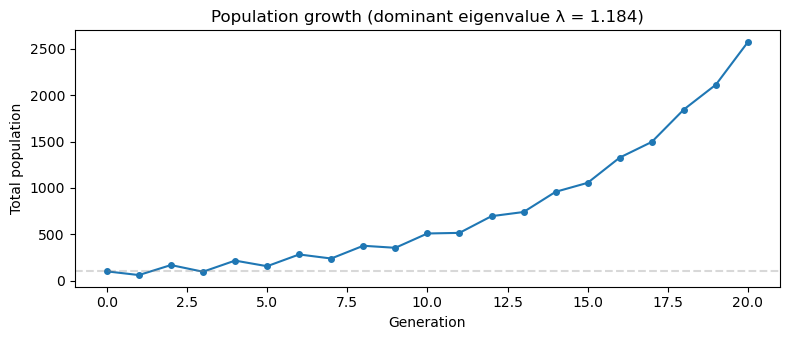

After 20 generations: started with 100, ended with 2573
Actual growth ratio (last two): 1.2178  (should approach 1.1843)


In [29]:
# Population dynamics: eigenvalues predict long-term growth
# A simple 3-age-class Leslie matrix

L_pop = np.array([
    [0,   2.0, 0.5],   # newborns produced by each age class
    [0.6, 0,   0],     # survival from age 0 → age 1
    [0,   0.8, 0]      # survival from age 1 → age 2
])

print("Leslie matrix L:")
print(L_pop)
print()

# Eigenvalues
pop_vals, pop_vecs = np.linalg.eig(L_pop)
dominant_idx = np.argmax(np.abs(pop_vals))
growth_rate = np.real(pop_vals[dominant_idx])
stable_dist = np.abs(pop_vecs[:, dominant_idx])
stable_dist = stable_dist / stable_dist.sum()

print(f"Dominant eigenvalue (growth rate): {growth_rate:.4f}")
print(f"  → Population {'grows' if growth_rate > 1 else 'declines'} by {abs(growth_rate-1)*100:.1f}% per generation")
print(f"Stable age distribution: {np.round(stable_dist, 3)}")
print(f"  → {stable_dist[0]*100:.0f}% juveniles, {stable_dist[1]*100:.0f}% young adults, {stable_dist[2]*100:.0f}% old adults")
print()

# Simulate: start with 100 juveniles, watch the population evolve
p = np.array([100, 0, 0], dtype=float)
totals = [p.sum()]
for t in range(20):
    p = L_pop @ p
    totals.append(p.sum())

fig, ax = plt.subplots(1, 1, figsize=(8, 3.5), dpi=100)
ax.plot(totals, 'o-', markersize=4)
ax.set_xlabel("Generation")
ax.set_ylabel("Total population")
ax.set_title(f"Population growth (dominant eigenvalue λ = {growth_rate:.3f})")
ax.axhline(y=totals[0], color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"After 20 generations: started with {totals[0]:.0f}, ended with {totals[-1]:.0f}")
print(f"Actual growth ratio (last two): {totals[-1]/totals[-2]:.4f}  (should approach {growth_rate:.4f})")

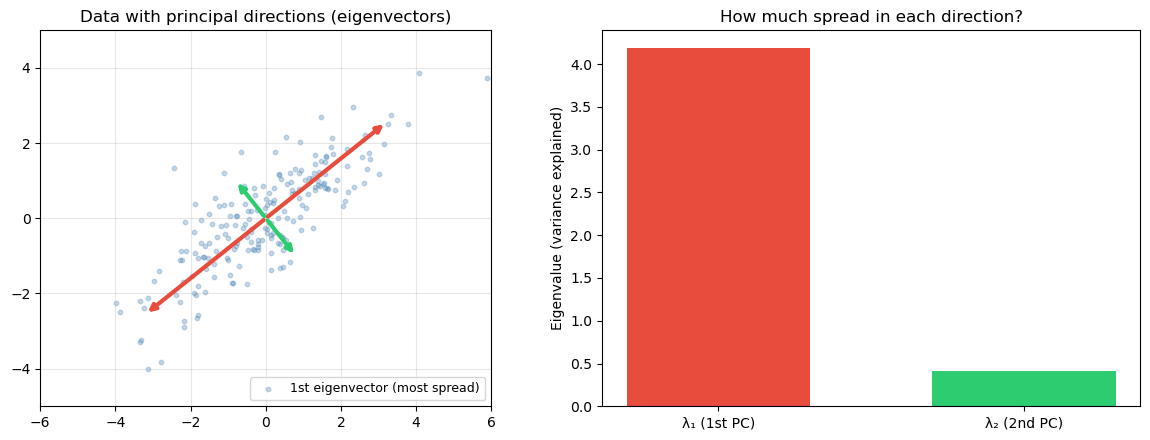

Eigenvalues: λ₁ = 4.185, λ₂ = 0.408
The first eigenvector captures 91.1% of the total variance.
If you could only keep one dimension, you'd project onto this eigenvector — that's PCA.


In [30]:
# PCA: eigenvectors of the covariance matrix find the "important directions" in data

# Generate some correlated 2D data
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2],
       [2, 2]]
data = np.random.multivariate_normal(mean, cov, 200)

# Compute eigenvectors of the covariance matrix
cov_matrix = np.cov(data.T)
pca_vals, pca_vecs = np.linalg.eigh(cov_matrix)

# Sort by decreasing eigenvalue
idx = np.argsort(pca_vals)[::-1]
pca_vals = pca_vals[idx]
pca_vecs = pca_vecs[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=100)

# Left: data with eigenvectors overlaid
ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], alpha=0.3, s=10, color='steelblue')
colors = ['#e74c3c', '#2ecc71']
labels = ['1st eigenvector (most spread)', '2nd eigenvector (least spread)']
for i in range(2):
    v = pca_vecs[:, i] * np.sqrt(pca_vals[i]) * 2
    ax.annotate('', xy=v, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
    ax.annotate('', xy=-v, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=3))
ax.set_xlim(-6, 6); ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.set_title("Data with principal directions (eigenvectors)")
ax.grid(alpha=0.3)
ax.legend(labels, loc='lower right', fontsize=9)

# Right: eigenvalue bar chart
ax = axes[1]
ax.bar([0, 1], pca_vals, color=colors, width=0.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['λ₁ (1st PC)', 'λ₂ (2nd PC)'])
ax.set_ylabel('Eigenvalue (variance explained)')
ax.set_title('How much spread in each direction?')

plt.tight_layout()
plt.show()

pct = pca_vals[0] / pca_vals.sum() * 100
print(f"Eigenvalues: λ₁ = {pca_vals[0]:.3f}, λ₂ = {pca_vals[1]:.3f}")
print(f"The first eigenvector captures {pct:.1f}% of the total variance.")
print("If you could only keep one dimension, you'd project onto this eigenvector — that's PCA.")

## 2.7 Building deeper eigenvector intuition

Let's spend more time sitting with eigenvectors. They're worth it.

### Why are eigenvectors "special"?

Imagine you're inside a room, and someone tells you: "I'm going to apply a transformation to every point in this room." Tables slide, chairs rotate, the floor stretches. Most things end up somewhere completely different from where they started.

But some directions — maybe a line from floor to ceiling — just get stretched or compressed. They don't twist, they don't tilt. Those are the eigenvectors.

Finding eigenvectors is finding the **grain of the transformation** — the directions it naturally works along. Once you know those directions, the entire transformation is easy to describe: it just stretches each direction by a different amount (the eigenvalue).

### The "what does the matrix *want* to do?" perspective

Think of a matrix as having preferences. When you apply it repeatedly:
- Directions with large eigenvalues get amplified
- Directions with small eigenvalues get suppressed
- Directions with eigenvalue exactly 1 are preserved
- Directions with eigenvalue 0 are destroyed

So the eigenvectors with the largest eigenvalues are the directions the matrix **most wants to point toward**. The dominant eigenvector is the matrix's "favorite direction" — the pattern it most naturally produces.

For a graph's adjacency matrix, the dominant eigenvector highlights the most central, well-connected nodes. For a covariance matrix, it points along the direction of greatest spread in the data. Same idea, different settings.

### Why are eigenvectors orthogonal? (for symmetric matrices)

For symmetric matrices — which includes all undirected graph matrices — eigenvectors are always orthogonal (perpendicular) to each other. Why?

Intuitively: a symmetric matrix doesn't rotate space, it only stretches it. And stretching picks out perpendicular axes (like squishing a sphere into an ellipsoid — the axes of the ellipsoid are perpendicular).

More formally: if $M\mathbf{u} = \lambda_1 \mathbf{u}$ and $M\mathbf{v} = \lambda_2 \mathbf{v}$ with $\lambda_1 \neq \lambda_2$, then:

$$\lambda_1 (\mathbf{u} \cdot \mathbf{v}) = (M\mathbf{u}) \cdot \mathbf{v} = \mathbf{u} \cdot (M\mathbf{v}) = \lambda_2 (\mathbf{u} \cdot \mathbf{v})$$

The middle equality uses symmetry ($M = M^\top$). Since $\lambda_1 \neq \lambda_2$, the only way this works is if $\mathbf{u} \cdot \mathbf{v} = 0$ — they're orthogonal.

This is a big deal: it means the eigenvectors give you a set of **completely independent directions** along which to decompose any vector. No redundancy, no overlap.

Eigenvalues: [0.7929 2.2071]
Dominant eigenvector: [-0.9239 -0.3827]



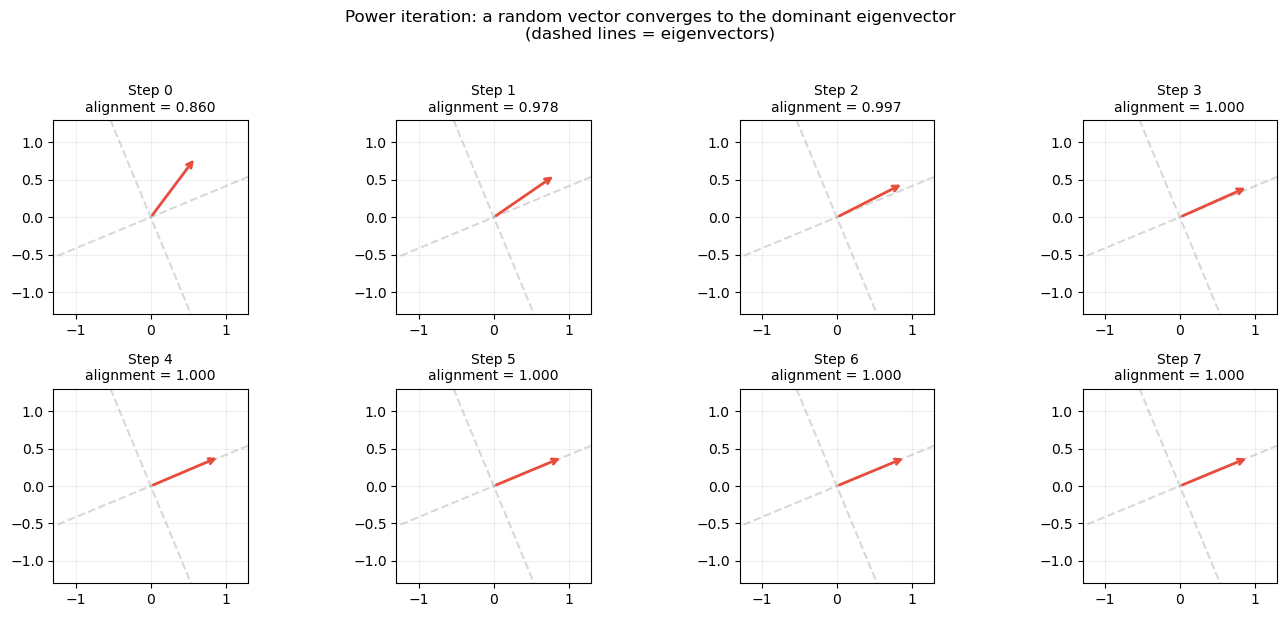

After repeated multiplication, ANY starting vector gets pulled toward
the dominant eigenvector. The matrix 'wants' to point in that direction.


In [31]:
# Watching a matrix amplify its favorite direction
# Start with a random vector and multiply by M repeatedly

M = np.array([[2.0, 0.5],
              [0.5, 1.0]])

vals_M, vecs_M = np.linalg.eigh(M)
print(f"Eigenvalues: {vals_M}")
print(f"Dominant eigenvector: {np.round(vecs_M[:, -1], 4)}")
print()

# Start with a random unit vector
x = np.array([0.6, 0.8])
x = x / np.linalg.norm(x)

fig, axes = plt.subplots(2, 4, figsize=(14, 6), dpi=100)

for step in range(8):
    ax = axes[step // 4, step % 4]

    # Plot the eigenvectors as reference lines
    for i in range(2):
        v = vecs_M[:, i]
        ax.plot([-v[0]*2, v[0]*2], [-v[1]*2, v[1]*2],
                color='gray', alpha=0.3, linestyle='--')

    # Plot current vector
    ax.annotate('', xy=x, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))

    # How aligned is x with the dominant eigenvector?
    alignment = abs(x @ vecs_M[:, -1])
    ax.set_title(f"Step {step}\nalignment = {alignment:.3f}", fontsize=10)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

    # Apply M and normalize
    x = M @ x
    x = x / np.linalg.norm(x)

plt.suptitle("Power iteration: a random vector converges to the dominant eigenvector\n"
             "(dashed lines = eigenvectors)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("After repeated multiplication, ANY starting vector gets pulled toward")
print("the dominant eigenvector. The matrix 'wants' to point in that direction.")

### Eigenvalues as a change of lens

Maybe the deepest way to think about eigenvalues: they give you a **new coordinate system** that's adapted to the matrix.

In the standard coordinate system (the $x$- and $y$-axes), a matrix does something complicated — it mixes the coordinates together. But if you switch to the eigenvector coordinate system, the matrix does something dead simple: it scales each coordinate independently.

It's like how a prism separates white light into its component colors. In the "white light" coordinate system, everything is mixed together. In the "spectrum" coordinate system, each component (color/frequency) is separate and independent.

| Standard coordinates | Eigenvector coordinates |
|:---|:---|
| $M\mathbf{x}$ mixes everything together | Each component scales independently |
| Hard to predict what $M^k\mathbf{x}$ looks like | $M^k$ just raises each eigenvalue to the $k$-th power |
| Complicated | Simple |

In [32]:
# Change of basis: see how a matrix becomes diagonal in eigenvector coordinates

M = np.array([[3, 1],
              [1, 2]], dtype=float)
vals, vecs = np.linalg.eigh(M)

print("M in standard coordinates:")
print(M)
print()

# Change to eigenvector coordinates: V^T M V = diagonal
M_eigen = vecs.T @ M @ vecs
print("M in eigenvector coordinates (should be diagonal):")
print(np.round(M_eigen, 10))
print()
print(f"Diagonal entries = eigenvalues: {np.round(np.diag(M_eigen), 4)}")
print()

# Demonstrate: apply M to a vector, in both coordinate systems
x = np.array([3, 1], dtype=float)
Mx_standard = M @ x

# In eigenvector coordinates
x_eigen = vecs.T @ x              # convert to eigenvector coords
Mx_eigen = vals * x_eigen          # just multiply by eigenvalues!
Mx_back = vecs @ Mx_eigen          # convert back

print(f"x = {x}")
print(f"M @ x (standard way) = {Mx_standard}")
print(f"M @ x (via eigenvalues) = {np.round(Mx_back, 10)}")
print(f"Same? {np.allclose(Mx_standard, Mx_back)}")
print()
print("In eigenvector coordinates, matrix multiplication is just entry-wise scaling.")
print("This is what makes eigenvalues so powerful.")

M in standard coordinates:
[[3. 1.]
 [1. 2.]]

M in eigenvector coordinates (should be diagonal):
[[1.382 0.   ]
 [0.    3.618]]

Diagonal entries = eigenvalues: [1.382 3.618]

x = [3. 1.]
M @ x (standard way) = [10.  5.]
M @ x (via eigenvalues) = [10.  5.]
Same? True

In eigenvector coordinates, matrix multiplication is just entry-wise scaling.
This is what makes eigenvalues so powerful.


## 2.8 Common questions and misconceptions

**"Do all matrices have eigenvectors?"**
All *square* matrices have eigenvalues (possibly complex numbers). But only **symmetric** matrices are guaranteed to have $n$ real eigenvalues with orthogonal eigenvectors. Since undirected graph matrices are always symmetric, we're in the nice case.

**"Are eigenvectors unique?"**
The *directions* are unique (for distinct eigenvalues), but the *length* and *sign* aren't — if $\mathbf{v}$ is an eigenvector, so is $-\mathbf{v}$ and $2\mathbf{v}$. We typically normalize to unit length. If two eigenvalues are equal ("degenerate"), any vector in the corresponding plane is an eigenvector.

**"Why do eigenvalues have that name?"**
"Eigen" is German for "own" or "characteristic." An eigenvector is a vector that *belongs to* the matrix — a direction that the matrix treats as its own. David Hilbert coined the term in 1904.

**"Can I always just look at the eigenvalues, or do I need the eigenvectors too?"**
Both carry information. The eigenvalues tell you *how much* (frequencies, growth rates, variances). The eigenvectors tell you *where* and *what pattern* (which nodes, which directions, which modes). Usually you need both.

## Your turn!

Take the next 10-15 minutes to go on a short rabbit hole.

Your goal is to find the **best explanation you can** of one or more of the following:
- What is an **eigenvalue**?
- What is an **eigenvector**?
- What do people mean by the **spectral properties** of a graph?
- Why do eigenvalues and eigenvectors show up so often in network science?

### What to bring back

Be ready to share:

1. One definition or description that you think is especially good.
2. Why you think it is good.
3. Anything else interesting that you find.

## From theory to graphs: a network's spectrum is its fingerprint

Let's make this concrete. Here are two small graphs. They look different, they have different wiring. But they happen to have the **same degree sequence** (every node has the same number of connections in both graphs).

The degree sequence can't tell them apart. Can the spectrum?

Degree sequence of G1: [3, 2, 2, 2, 2, 1]
Degree sequence of G2: [3, 2, 2, 2, 2, 1]


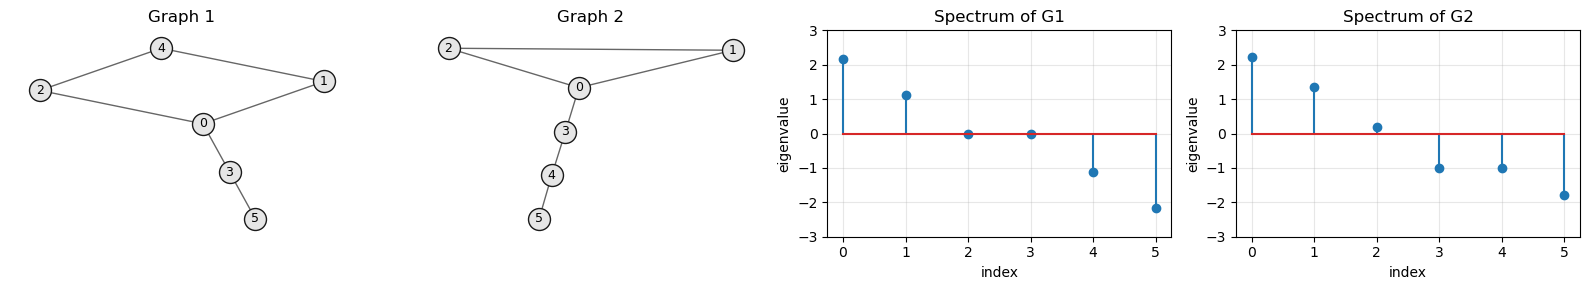


G1 eigenvalues: [ 2.175  1.126  0.    -0.    -1.126 -2.175]
G2 eigenvalues: [ 2.228  1.36   0.186 -1.    -1.    -1.775]

Same degree sequence? True
Same spectrum? False


In [33]:
# Two graphs with the same degree sequence but different structure
G1 = nx.Graph([(0,1),(0,2),(0,3),(1,4),(2,4),(3,5)])
G2 = nx.Graph([(0,1),(0,2),(0,3),(1,2),(3,4),(4,5)])

print("Degree sequence of G1:", sorted([d for _, d in G1.degree()], reverse=True))
print("Degree sequence of G2:", sorted([d for _, d in G2.degree()], reverse=True))

# Compute their spectra (eigenvalues of the adjacency matrix)
A1, _ = adjacency_dense(G1)
A2, _ = adjacency_dense(G2)
eigs1 = np.sort(np.linalg.eigvalsh(A1))[::-1]
eigs2 = np.sort(np.linalg.eigvalsh(A2))[::-1]

fig, axes = plt.subplots(1, 4, figsize=(16, 3), dpi=100)

draw_graph(G1, axes[0], title="Graph 1")
draw_graph(G2, axes[1], title="Graph 2")

axes[2].stem(range(len(eigs1)), eigs1)
axes[2].set_title("Spectrum of G1")
axes[2].set_xlabel("index")
axes[2].set_ylabel("eigenvalue")
axes[2].set_ylim(-3, 3)
axes[2].grid(alpha=0.3)

axes[3].stem(range(len(eigs2)), eigs2)
axes[3].set_title("Spectrum of G2")
axes[3].set_xlabel("index")
axes[3].set_ylabel("eigenvalue")
axes[3].set_ylim(-3, 3)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nG1 eigenvalues: {np.round(eigs1, 3)}")
print(f"G2 eigenvalues: {np.round(eigs2, 3)}")
print(f"\nSame degree sequence? {sorted([d for _,d in G1.degree()]) == sorted([d for _,d in G2.degree()])}")
print(f"Same spectrum? {np.allclose(eigs1, eigs2)}")

The spectra are **different**. The spectrum sees structural differences that the degree sequence misses.

Now let's check the other direction — two graphs that *look* different (different layouts) but are actually the same graph (isomorphic):

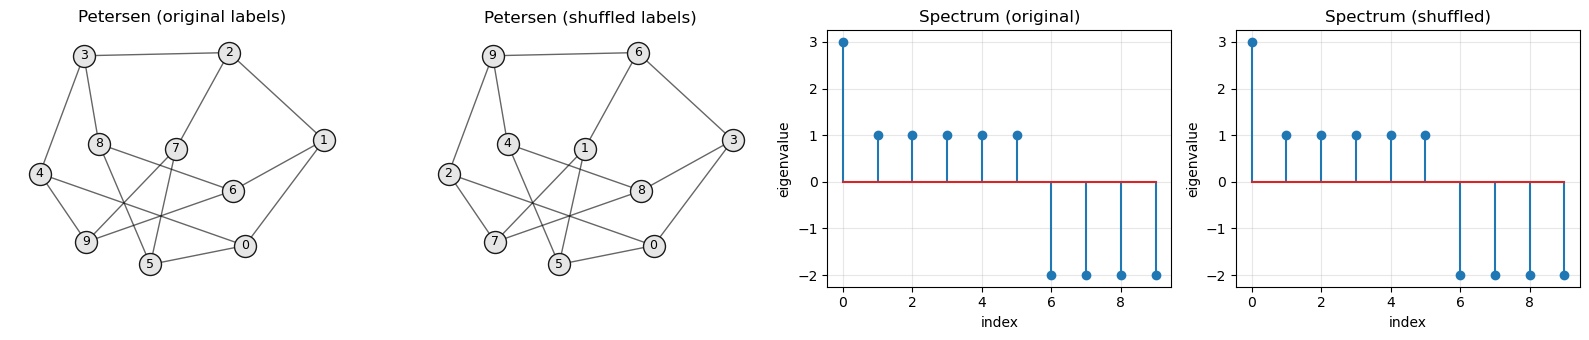

Same spectrum? True


In [34]:
# The same graph drawn two different ways (relabel the nodes)
G_orig = nx.petersen_graph()
mapping = {i: (i * 3) % 10 for i in range(10)}  # shuffle node labels
G_shuffled = nx.relabel_nodes(G_orig, mapping)

eigs_orig = np.sort(np.linalg.eigvalsh(nx.to_numpy_array(G_orig)))[::-1]
eigs_shuf = np.sort(np.linalg.eigvalsh(nx.to_numpy_array(G_shuffled)))[::-1]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), dpi=100)

draw_graph(G_orig, axes[0], title="Petersen (original labels)")
draw_graph(G_shuffled, axes[1], title="Petersen (shuffled labels)")

axes[2].stem(range(len(eigs_orig)), eigs_orig)
axes[2].set_title("Spectrum (original)")
axes[2].set_xlabel("index"); axes[2].set_ylabel("eigenvalue")
axes[2].grid(alpha=0.3)

axes[3].stem(range(len(eigs_shuf)), eigs_shuf)
axes[3].set_title("Spectrum (shuffled)")
axes[3].set_xlabel("index"); axes[3].set_ylabel("eigenvalue")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Same spectrum?", np.allclose(eigs_orig, eigs_shuf))

**Same spectrum.** The spectrum sees *through* the node labeling to the underlying structure. It doesn't care how you draw the graph or what you name the nodes.

So the spectrum is a structural fingerprint: different structures generally produce different spectra, and rearranging the labels doesn't change it.

> **A network's spectrum is to a network what an emission spectrum is to a chemical element — a compact signature of internal structure.**

The rest of this class is about understanding *what* that spectrum is, *how* to compute it, and *what it tells us*.

---

# Part 3 — Signals and Vibrations on a Network

Now let's apply what we've learned to graphs. To understand the spectrum of a network, we need a language for talking about **patterns on a graph**.

## 3.1 Node signals: putting numbers on nodes

A **node signal** is just a number assigned to each node. Think of it as a height, a temperature, or an opinion.

$$\mathbf{x} = \begin{pmatrix} x_0 \\ x_1 \\ \vdots \\ x_{n-1} \end{pmatrix} \in \mathbb{R}^n$$

For example, on a 6-node path graph, here are three different signals:

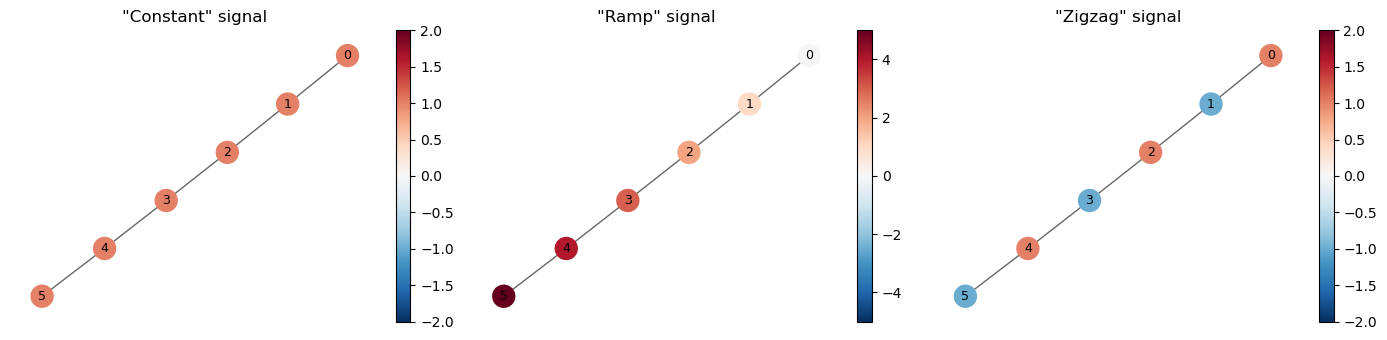

In [35]:
pos_path = nx.kamada_kawai_layout(G_path6)

x_constant = np.array([1, 1, 1, 1, 1, 1], dtype=float)
x_ramp = np.array([0, 1, 2, 3, 4, 5], dtype=float)
x_zigzag = np.array([1, -1, 1, -1, 1, -1], dtype=float)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=100)
vmin, vmax = -1.5, 5.5

draw_graph(G_path6, axes[0], pos=pos_path, values=x_constant, title='"Constant" signal',
           cmap="RdBu_r", vmin=-2, vmax=2)
draw_graph(G_path6, axes[1], pos=pos_path, values=x_ramp, title='"Ramp" signal',
           cmap="RdBu_r", vmin=-5, vmax=5)
draw_graph(G_path6, axes[2], pos=pos_path, values=x_zigzag, title='"Zigzag" signal',
           cmap="RdBu_r", vmin=-2, vmax=2)

plt.tight_layout()
plt.show()

Look at these three signals and notice something:

- The **constant** signal: every neighbor agrees. Zero tension.
- The **ramp** signal: neighbors are close but not identical. Some tension.
- The **zigzag** signal: every neighbor **maximally disagrees**. Maximum tension.

This notion of "how much do neighbors disagree" turns out to be exactly what eigenvalues measure on a graph.

## 3.2 Measuring roughness: the tension of a signal

Let's make "neighbor disagreement" precise. For every edge in the graph, we can measure the squared difference between the two endpoints:

$$\text{roughness}(\mathbf{x}) = \sum_{(u,v) \in E} (x_u - x_v)^2$$

- If neighbors have similar values, each term is small → low roughness.
- If neighbors have very different values, the terms are large → high roughness.
- If the signal is constant, every term is zero → **zero roughness**.

Physically: if each node is a little mass and each edge is a spring, the roughness is the **total elastic energy** in the springs. Smooth signals have low energy; jagged signals have high energy.

In [36]:
def roughness(G, x):
    """Sum of (x_u - x_v)^2 over all edges."""
    return sum((x[u] - x[v])**2 for u, v in G.edges())

print(f"Constant signal roughness:  {roughness(G_path6, x_constant):.1f}")
print(f"Ramp signal roughness:      {roughness(G_path6, x_ramp):.1f}")
print(f"Zigzag signal roughness:    {roughness(G_path6, x_zigzag):.1f}")

Constant signal roughness:  0.0
Ramp signal roughness:      5.0
Zigzag signal roughness:    20.0


The ordering matches our intuition: constant (0) < ramp (5) < zigzag (20).

Now here's a question that will lead us straight to eigenvectors:

## 3.3 Your turn: find the smoothest non-trivial signal!

The constant signal has zero roughness, but it's boring — it tells us nothing about the structure of the graph. (It would be the same on *any* graph.)

**Challenge:** On the 6-node path graph below, can you find a signal that:
- Is **not constant** (not all the same value)
- Has the **lowest roughness** you can manage
- Is **normalized**: $\sum_i x_i^2 = 6$ (so you can't cheat by making everything tiny)
- Is **orthogonal to the constant signal**: $\sum_i x_i = 0$ (positive and negative values must balance out)

Try a few different patterns. Use the cell below to test them.

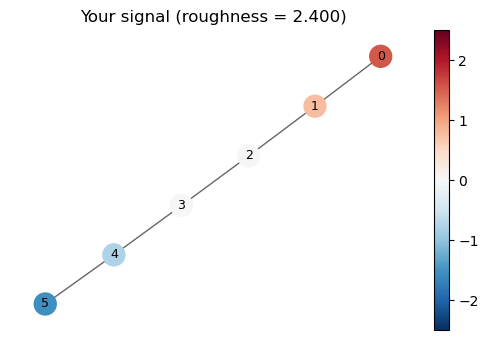

Signal values: [ 1.549  0.775  0.     0.    -0.775 -1.549]
Sum:           0.000000  (should be ≈ 0)
Sum of squares: 6.000000  (should be ≈ 6)
Roughness:     2.4000

Can you get below 2.0?


In [37]:
# YOUR EXPERIMENT: try different signals!
# Replace the values below with your own guesses.
# The constraints are: sum(x) = 0 and sum(x^2) = 6.

my_signal = np.array([2, 1, 0, 0, -1, -2], dtype=float)  # <-- edit this!

# Normalize to satisfy the constraints
my_signal = my_signal - my_signal.mean()  # center (sum = 0)
my_signal = my_signal * np.sqrt(6 / np.sum(my_signal**2))  # scale (sum of squares = 6)

r = roughness(G_path6, my_signal)

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), dpi=100)
draw_graph(G_path6, ax, pos=pos_path, values=my_signal, title=f"Your signal (roughness = {r:.3f})",
           cmap="RdBu_r", vmin=-2.5, vmax=2.5)
plt.tight_layout()
plt.show()

print(f"Signal values: {np.round(my_signal, 3)}")
print(f"Sum:           {my_signal.sum():.6f}  (should be ≈ 0)")
print(f"Sum of squares: {np.sum(my_signal**2):.6f}  (should be ≈ 6)")
print(f"Roughness:     {r:.4f}")
print(f"\nCan you get below 2.0?")

### The answer: the Fiedler vector

The signal with the absolute lowest roughness (subject to our constraints) is called the **Fiedler vector**. Let's compute it and see what it looks like.

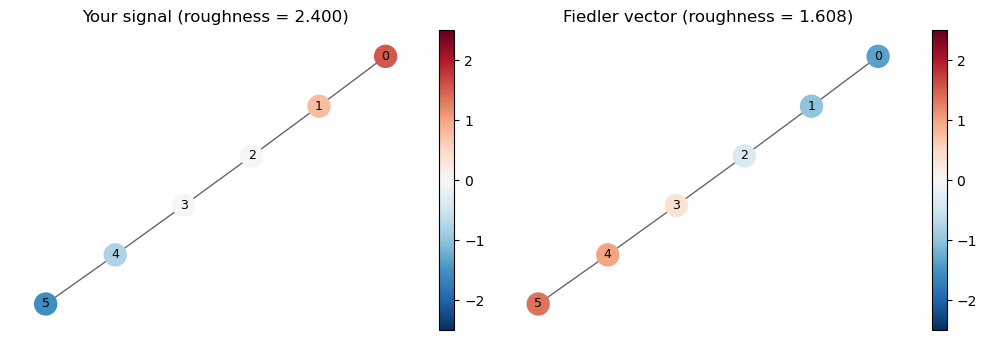

Fiedler vector values: [-1.366 -1.    -0.366  0.366  1.     1.366]
Fiedler roughness:     1.6077

This is the mathematically optimal answer — no other signal can do better.


In [38]:
def laplacian_from_adjacency(A):
    """Combinatorial Laplacian L = D - A."""
    D = np.diag(np.asarray(A.sum(axis=1)).ravel())
    return D - A

def eigh_sorted(M):
    """Eigenpairs of a symmetric dense matrix, sorted by increasing eigenvalue."""
    Md = M.toarray() if sp.issparse(M) else np.asarray(M)
    vals, vecs = np.linalg.eigh(Md)
    idx = np.argsort(vals)
    return vals[idx], vecs[:, idx]

def normalize_sign(v):
    """Flip an eigenvector sign so its largest-magnitude entry is positive."""
    v = np.asarray(v, dtype=float).copy()
    if v[np.argmax(np.abs(v))] < 0:
        v *= -1.0
    return v

# Compute the Laplacian and its eigenvectors
A_path, nodes_path = adjacency_dense(G_path6)
L_path = laplacian_from_adjacency(A_path)
vals_path, vecs_path = eigh_sorted(L_path)

# The Fiedler vector is eigenvector #1 (index 1, since index 0 is the constant vector)
fiedler = normalize_sign(vecs_path[:, 1])
fiedler_scaled = fiedler * np.sqrt(6 / np.sum(fiedler**2))  # same normalization as above

r_fiedler = roughness(G_path6, fiedler_scaled)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)

draw_graph(G_path6, axes[0], pos=pos_path, values=my_signal,
           title=f"Your signal (roughness = {roughness(G_path6, my_signal):.3f})",
           cmap="RdBu_r", vmin=-2.5, vmax=2.5)
draw_graph(G_path6, axes[1], pos=pos_path, values=fiedler_scaled,
           title=f"Fiedler vector (roughness = {r_fiedler:.3f})",
           cmap="RdBu_r", vmin=-2.5, vmax=2.5)

plt.tight_layout()
plt.show()

print(f"Fiedler vector values: {np.round(fiedler_scaled, 3)}")
print(f"Fiedler roughness:     {r_fiedler:.4f}")
print(f"\nThis is the mathematically optimal answer — no other signal can do better.")

Notice the shape: the Fiedler vector is a **slow wave** across the graph. It changes gradually from one end to the other. This is exactly analogous to the **fundamental mode** of a vibrating string — the lowest-frequency standing wave.

And this is no coincidence. The Fiedler vector *is* the fundamental vibration mode of the network.

## 3.4 All the vibration modes

Just like a drum has a whole series of vibration modes — fundamental, first overtone, second overtone, etc. — a network has **one mode for each node**.

Let's look at all of them for our 6-node path:

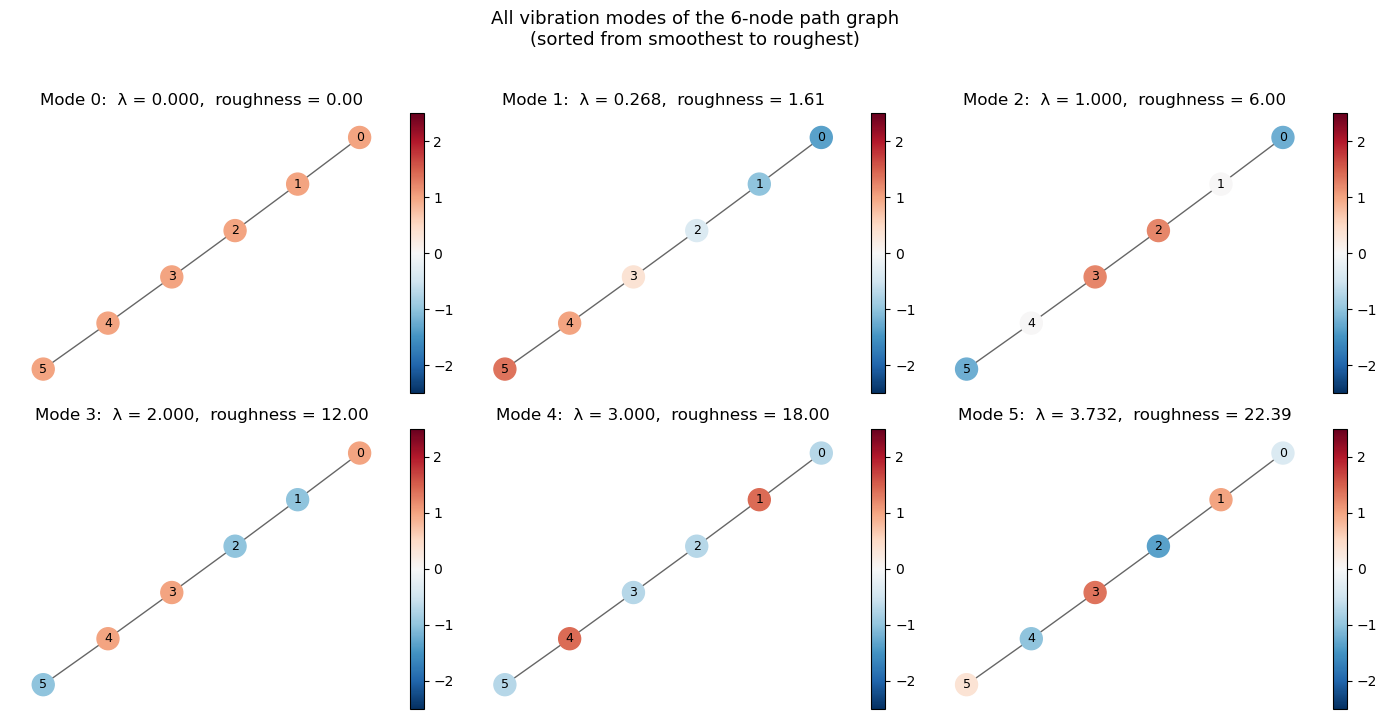

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), dpi=100)

for k, ax in enumerate(axes.ravel()):
    vec = normalize_sign(vecs_path[:, k])
    vec_scaled = vec * np.sqrt(6 / np.sum(vec**2))
    r = roughness(G_path6, vec_scaled)
    draw_graph(G_path6, ax, pos=pos_path, values=vec_scaled,
               title=f"Mode {k}:  λ = {vals_path[k]:.3f},  roughness = {r:.2f}",
               cmap="RdBu_r", vmin=-2.5, vmax=2.5)

plt.suptitle("All vibration modes of the 6-node path graph\n(sorted from smoothest to roughest)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Read this picture like a musical scale:

| Mode | Eigenvalue $\lambda$ | What it looks like | Musical analogy |
|:----:|:---:|:---|:---|
| 0 | 0 | All nodes the same color | Silence (DC offset) |
| 1 | small | Slow gradient across the graph | Fundamental frequency |
| 2 | medium | One more wiggle | First overtone |
| ... | ... | ... | ... |
| $n-1$ | large | Maximally jagged: neighbors alternate | Highest pitch |

**The eigenvalue IS the roughness** (up to normalization). Low eigenvalue = smooth mode = low frequency. High eigenvalue = rough mode = high frequency.

This is the drum analogy, made precise:

> **The eigenvectors are the allowed vibration patterns. The eigenvalues are their frequencies. Together they form the spectrum.**

## 3.5 The same modes on different graphs

Different graph shapes produce different vibration patterns — just like different drum shapes. Let's compare the path, cycle, star, and clique:

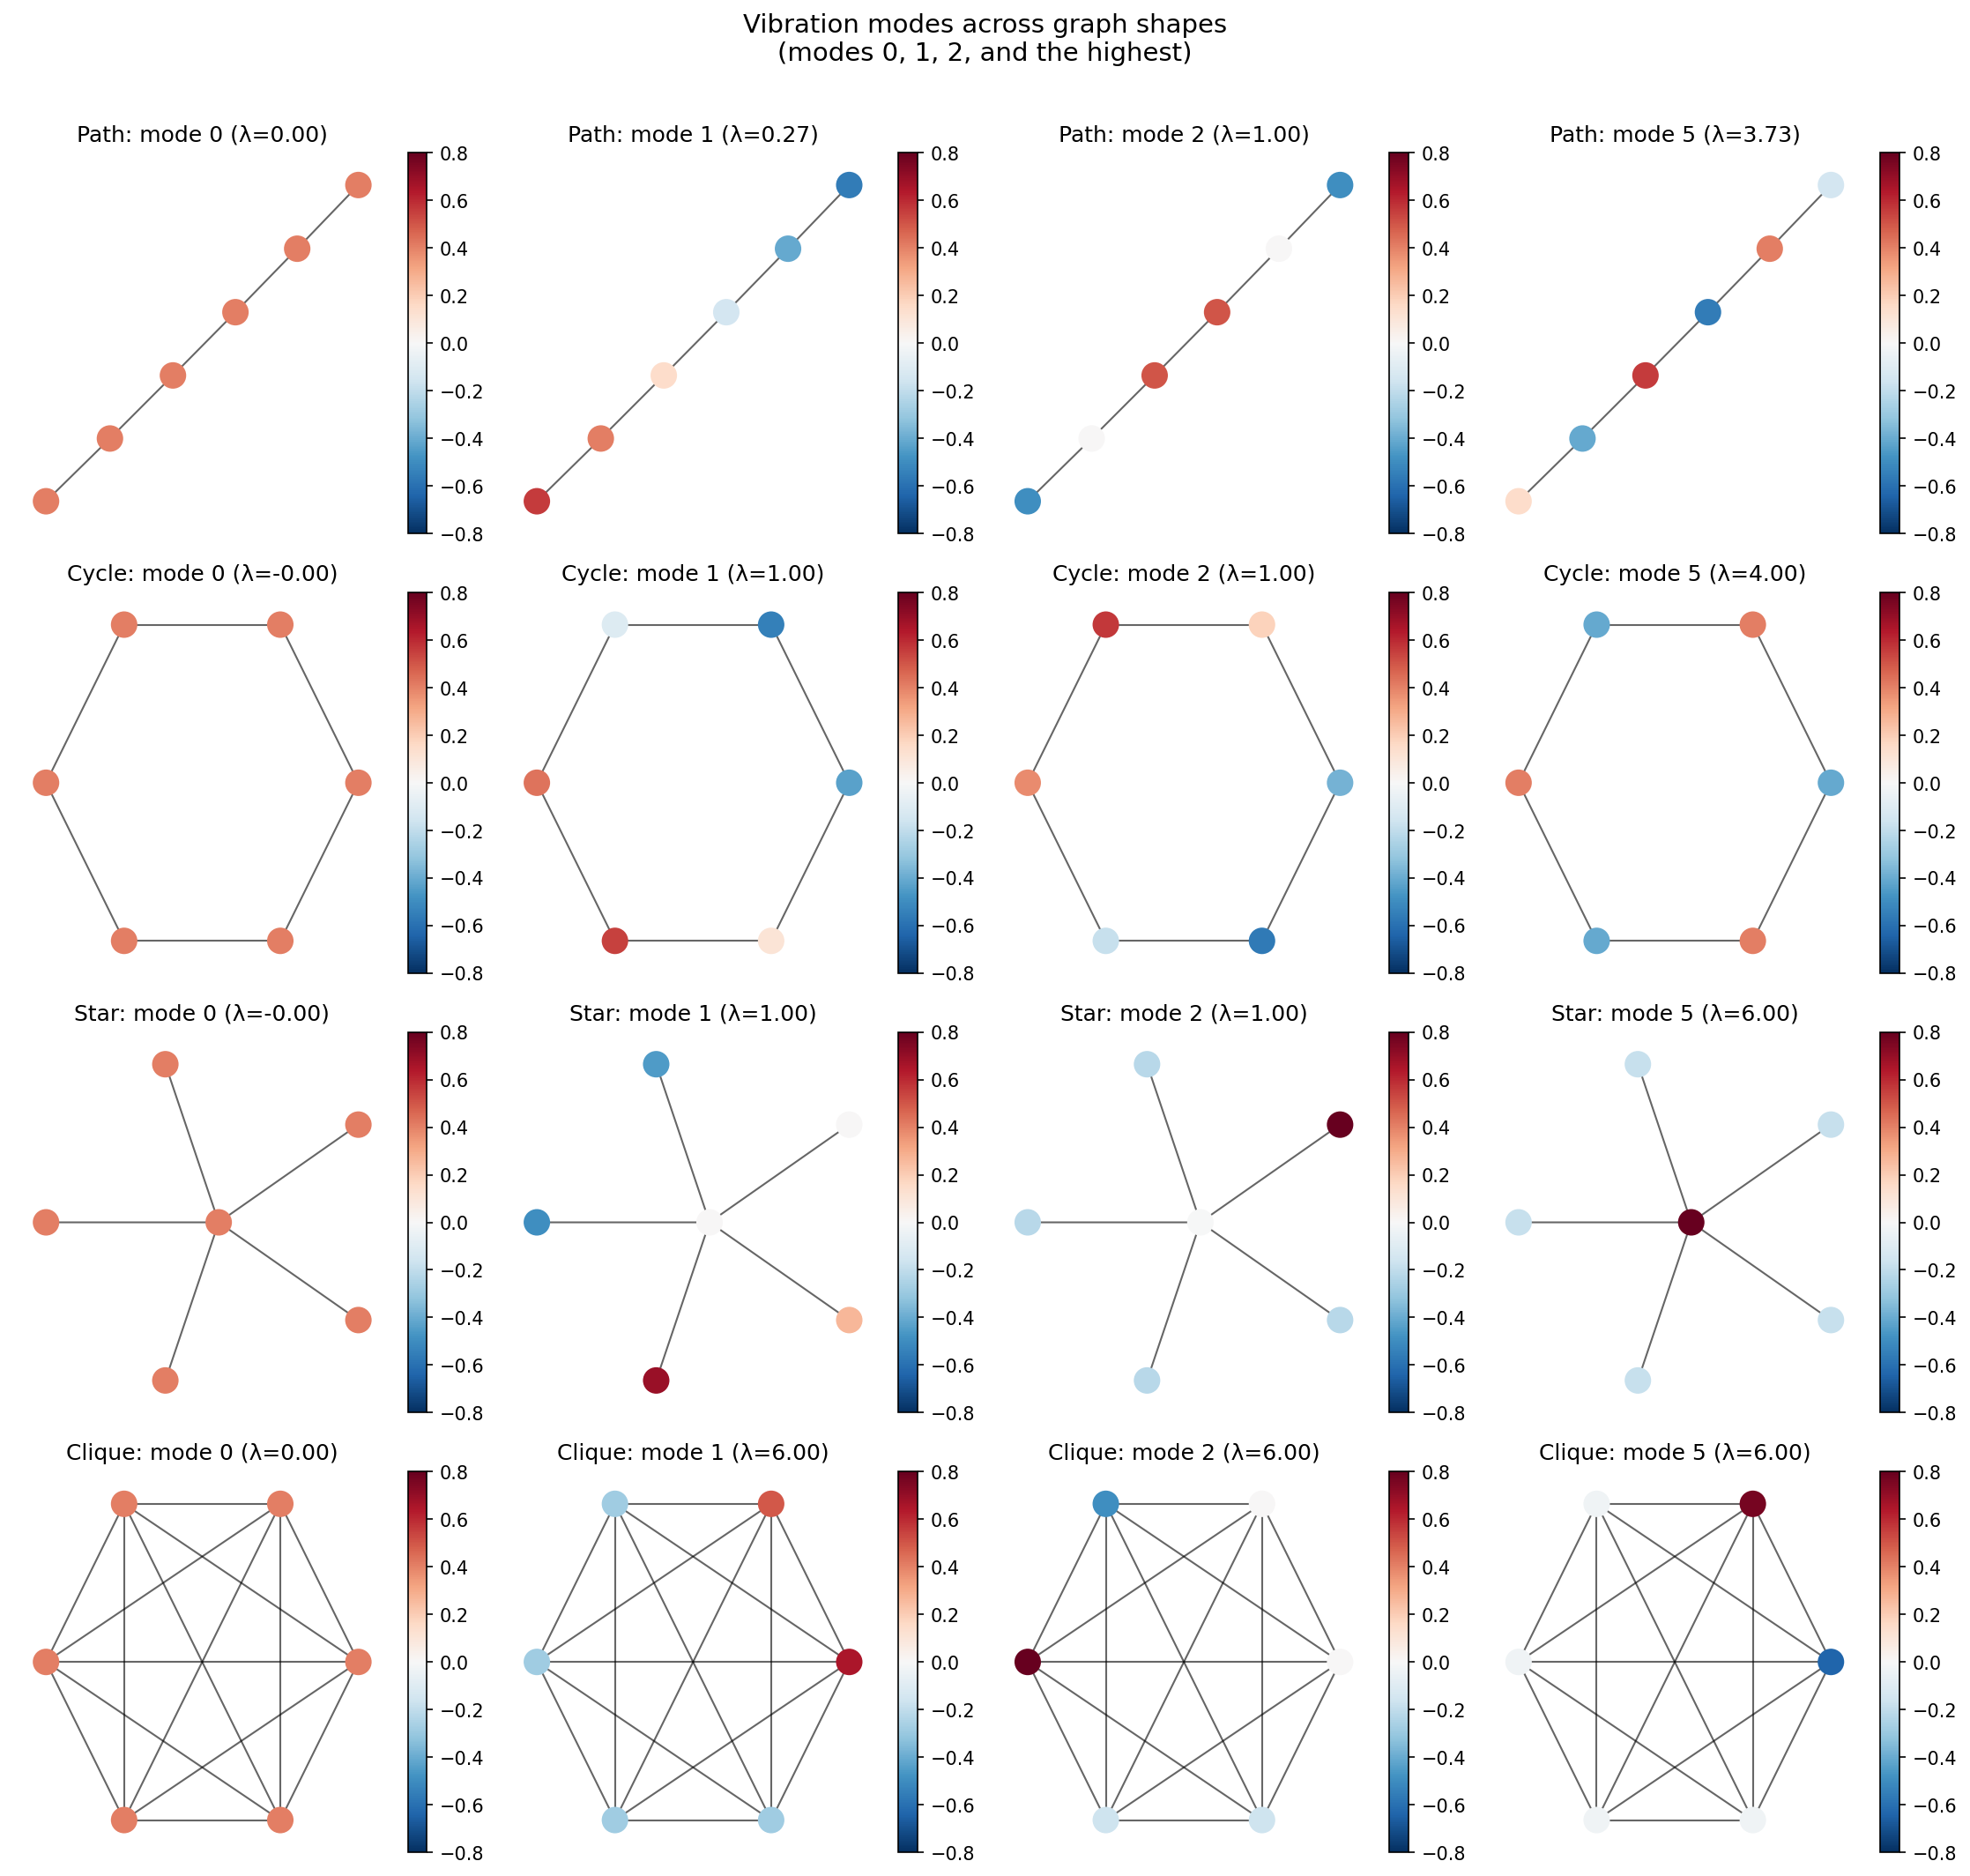

In [40]:
graphs = {"Path": G_path6, "Cycle": G_cycle6, "Star": G_star6, "Clique": G_clique6}

fig, axes = plt.subplots(4, 4, figsize=(15, 14), dpi=150)

for row, (name, G) in enumerate(graphs.items()):
    A, nodes = adjacency_dense(G)
    L = laplacian_from_adjacency(A)
    vals, vecs = eigh_sorted(L)
    pos = nx.kamada_kawai_layout(G)
    for col in range(4):
        k = col if col < 3 else len(vals) - 1  # show modes 0, 1, 2, and the last one
        vec = normalize_sign(vecs[:, k])
        mode_label = k if col < 3 else f"{len(vals)-1}"
        draw_graph(G, axes[row, col], pos=pos, values=vec,
                   title=f"{name}: mode {mode_label} (λ={vals[k]:.2f})",
                   cmap="RdBu_r", vmin=-0.8, vmax=0.8, with_labels=False, node_size=180)

plt.suptitle("Vibration modes across graph shapes\n(modes 0, 1, 2, and the highest)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Notice how the modes reflect the *geometry* of each graph:
- **Path**: modes look like standing waves on a string.
- **Cycle**: modes look like waves going around a ring.
- **Star**: modes separate the hub from the leaves.
- **Clique**: every node is equivalent, so the modes are less visually distinct.

The spectrum encodes the geometry. Different shapes, different spectra.

---

# Part 4 — Eigenvalues on Graphs

We've now seen eigenvectors and eigenvalues in the abstract — the vibration patterns and their frequencies. Now let's watch them work on actual graphs.

## 4.1 The matrix acts on a signal

The adjacency matrix $A$ lets us **aggregate neighbor values**. If $\mathbf{x}$ is a node signal, then:

$$(A\mathbf{x})_i = \sum_{j : (i,j) \in E} x_j = \text{sum of the signal values on node } i\text{'s neighbors}$$

Put a signal on the nodes, multiply by the matrix, get a new signal back.

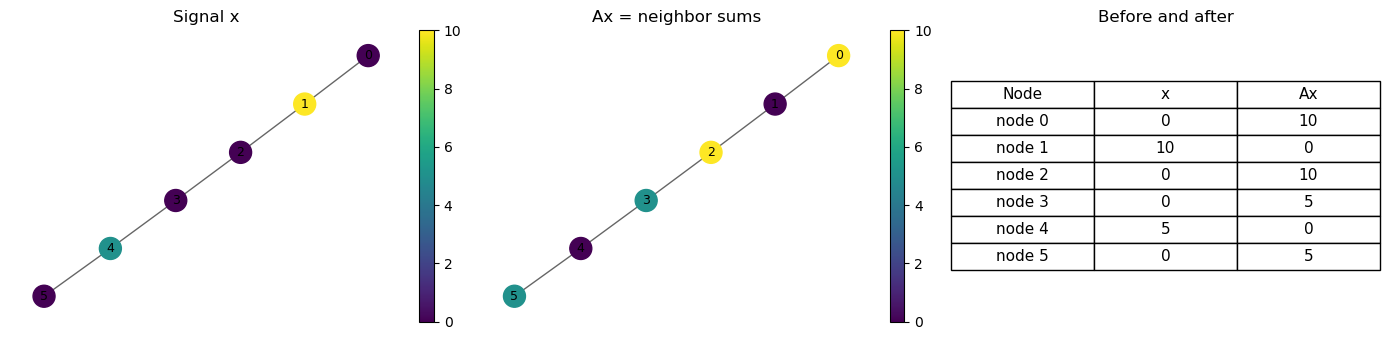

Node 0's neighbors are [1]. Sum of their values: 10
Node 1's neighbors are [0, 2]. Sum of their values: 0 + 0 = 0
Node 4's neighbors are [3, 5]. Sum of their values: 0 + 0 = 0


In [41]:
# Demonstrate: Ax = "sum of neighbors"
x = np.array([0, 10, 0, 0, 5, 0], dtype=float)
y = A_path @ x

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=100)

draw_graph(G_path6, axes[0], pos=pos_path, values=x, title="Signal x",
           cmap="viridis", vmin=0, vmax=10)
draw_graph(G_path6, axes[1], pos=pos_path, values=y, title="Ax = neighbor sums",
           cmap="viridis", vmin=0, vmax=10)

# Show as a table
axes[2].set_axis_off()
table_data = [[f"node {i}", f"{x[i]:.0f}", f"{y[i]:.0f}"] for i in range(6)]
table = axes[2].table(cellText=table_data, colLabels=["Node", "x", "Ax"],
                       loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
axes[2].set_title("Before and after")

plt.tight_layout()
plt.show()

print("Node 0's neighbors are [1]. Sum of their values: 10")
print("Node 1's neighbors are [0, 2]. Sum of their values: 0 + 0 = 0")
print("Node 4's neighbors are [3, 5]. Sum of their values: 0 + 0 = 0")

So multiplying by $A$ *transforms* the signal. For a generic signal, the shape changes completely — the pattern of highs and lows gets rearranged.

But what if we could find a signal whose **shape doesn't change** when we multiply by the matrix?

## 4.2 Eigenvectors: patterns that keep their shape

An **eigenvector** of a matrix $M$ is a signal $\mathbf{v}$ such that multiplying by $M$ only **scales** the signal — it doesn't change its shape:

$$M\mathbf{v} = \lambda \mathbf{v}$$

- $\mathbf{v}$ is the eigenvector — a special direction that the matrix doesn't distort.
- $\lambda$ is the eigenvalue — the scale factor. How much does the matrix amplify (or shrink) this particular pattern?

For a graph matrix:

> **An eigenvector is a node-signal pattern that, after neighbor-aggregation, comes back with the same shape but a different amplitude.**

Let's see this concretely.

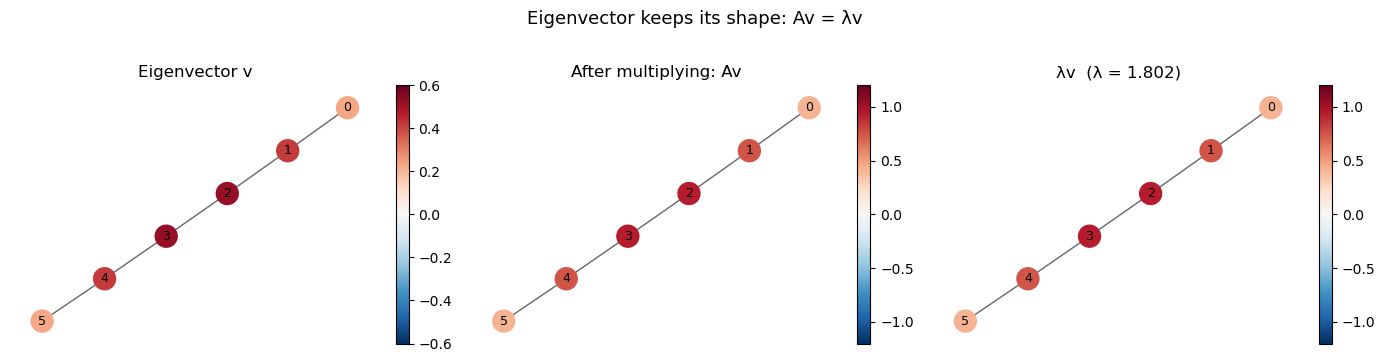

v  = [0.2319 0.4179 0.5211 0.5211 0.4179 0.2319]
Av = [0.4179 0.753  0.939  0.939  0.753  0.4179]
λv = [0.4179 0.753  0.939  0.939  0.753  0.4179]

Av ≈ λv? True


In [42]:
# Compute adjacency eigenvectors of the path graph
vals_A, vecs_A = eigh_sorted(A_path)

# Pick the dominant eigenvector (last one, since eigh sorts in increasing order)
v_dom = normalize_sign(vecs_A[:, -1])
lam_dom = vals_A[-1]

Av = A_path @ v_dom  # multiply by A

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=100)

draw_graph(G_path6, axes[0], pos=pos_path, values=v_dom,
           title="Eigenvector v", cmap="RdBu_r", vmin=-0.6, vmax=0.6)
draw_graph(G_path6, axes[1], pos=pos_path, values=Av,
           title="After multiplying: Av", cmap="RdBu_r", vmin=-1.2, vmax=1.2)
draw_graph(G_path6, axes[2], pos=pos_path, values=lam_dom * v_dom,
           title=f"λv  (λ = {lam_dom:.3f})", cmap="RdBu_r", vmin=-1.2, vmax=1.2)

plt.suptitle("Eigenvector keeps its shape: Av = λv", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"v  = {np.round(v_dom, 4)}")
print(f"Av = {np.round(Av, 4)}")
print(f"λv = {np.round(lam_dom * v_dom, 4)}")
print(f"\nAv ≈ λv? {np.allclose(Av, lam_dom * v_dom)}")

**The middle and right panels look the same** — because $A\mathbf{v}$ *is* $\lambda\mathbf{v}$. The matrix just scaled the signal; it didn't change the pattern.

Now compare with a **generic** (non-eigen) signal:

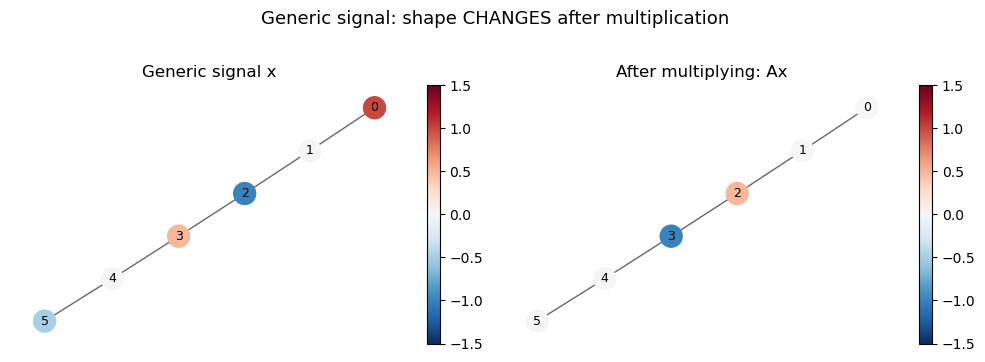

x  = [ 1.   0.  -1.   0.5  0.  -0.5]
Ax = [ 0.   0.   0.5 -1.   0.   0. ]

The pattern is completely different. This is NOT an eigenvector.


In [43]:
# Generic signal — NOT an eigenvector
x_generic = np.array([1, 0, -1, 0.5, 0, -0.5], dtype=float)
Ax_generic = A_path @ x_generic

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)

draw_graph(G_path6, axes[0], pos=pos_path, values=x_generic,
           title="Generic signal x", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
draw_graph(G_path6, axes[1], pos=pos_path, values=Ax_generic,
           title="After multiplying: Ax", cmap="RdBu_r", vmin=-1.5, vmax=1.5)

plt.suptitle("Generic signal: shape CHANGES after multiplication", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"x  = {x_generic}")
print(f"Ax = {np.round(Ax_generic, 4)}")
print(f"\nThe pattern is completely different. This is NOT an eigenvector.")

So to summarize:

| | Generic signal | Eigenvector |
|:---|:---|:---|
| Multiply by $M$ | Shape changes | Shape is preserved |
| $M\mathbf{x}$ equals | some new vector | $\lambda \mathbf{x}$ (just scaled) |
| Analogy | Noise — all frequencies mixed | Pure tone — single frequency |

## 4.3 The geometric picture on graphs

We saw the circle-to-ellipse picture in Part 2 for abstract matrices. The same idea applies to graph matrices: the "circle" is the set of all unit-norm node signals, and the "ellipse" is what you get after one round of neighbor-aggregation. The eigenvectors are the signals that come back pointing in the same direction.

In [44]:
# The same circle-to-ellipse idea, but now on the graph's adjacency matrix
# (See Part 2 for the full geometric visualization)
print("Adjacency matrix eigenvalues:", np.round(vals_A, 3))
print()
print("The largest eigenvalue ({:.3f}) corresponds to the smoothest pattern.".format(vals_A[-1]))
print("The smallest eigenvalue ({:.3f}) corresponds to the roughest pattern.".format(vals_A[0]))

Adjacency matrix eigenvalues: [-1.802 -1.247 -0.445  0.445  1.247  1.802]

The largest eigenvalue (1.802) corresponds to the smoothest pattern.
The smallest eigenvalue (-1.802) corresponds to the roughest pattern.


The eigenvalues of the adjacency matrix range from most negative (roughest vibration) to most positive (smoothest). Each eigenvalue tells you how much the matrix amplifies that particular vibration pattern.

## 4.4 Connecting the two pictures

We now have two ways to think about eigenvectors:

| Perspective | Eigenvector is... | Eigenvalue is... |
|:---|:---|:---|
| **Vibration** (Part 3) | A standing-wave pattern on the graph | The frequency (roughness) of that pattern |
| **Algebra** (Part 2) | A direction the matrix doesn't distort | The scale factor along that direction |

These are the *same thing* viewed from different angles. The Laplacian's eigenvectors are vibration modes, and their eigenvalues measure roughness. The adjacency matrix's eigenvectors are the patterns most amplified by neighbor-averaging.

Every $n$-node graph has exactly $n$ eigenvectors (for each of its matrices). Together they form a **complete basis** — any signal on the graph can be written as a sum of these modes:

$$\mathbf{x} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \cdots + c_n \mathbf{v}_n$$

This is the **graph Fourier transform** — decomposing an arbitrary signal into its frequency components, just like Fourier analysis decomposes sound into sine waves.

## 4.5 Power iteration: why repeated averaging finds the dominant eigenvector

Start with *any* random signal and multiply by $A$ over and over:

$$\mathbf{x} \to A\mathbf{x} \to A^2\mathbf{x} \to A^3\mathbf{x} \to \cdots$$

Each multiplication amplifies every eigenvector component by its eigenvalue. The component with the **largest** eigenvalue gets amplified the most, and eventually dominates. Like turning up the volume on a stereo — every frequency gets louder, but the loudest one drowns out the rest.

This process is called **power iteration**, and it converges to the **dominant eigenvector** — the pattern that most "agrees" with the structure.

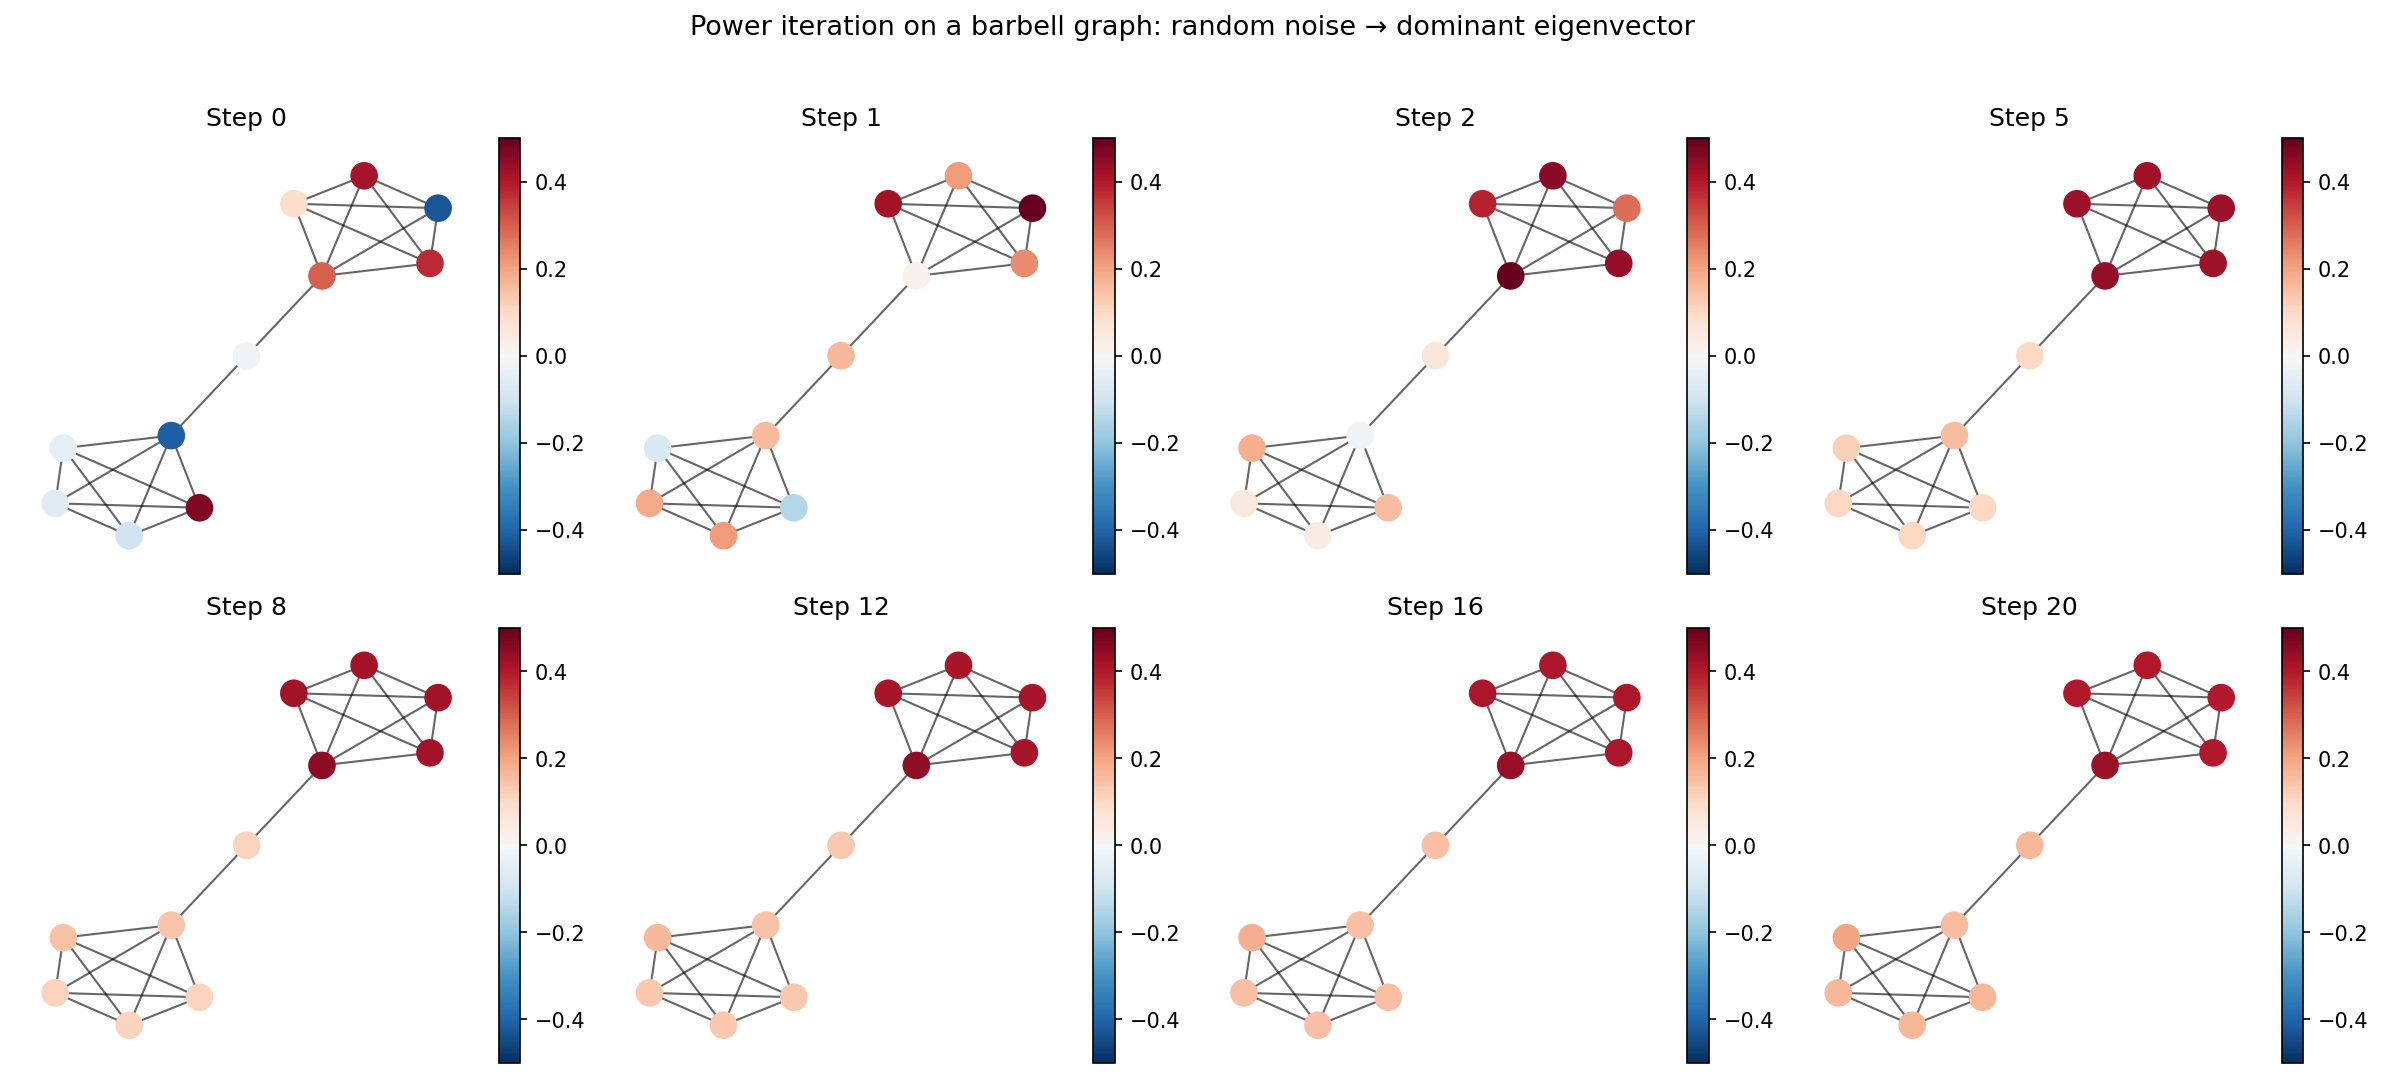

The random initial signal gradually converges to a stable pattern.
That pattern is the dominant eigenvector — the signal most amplified by neighbor-averaging.


In [45]:
def unit(v):
    """Normalize a vector to unit length."""
    return v / np.linalg.norm(v)

def power_iteration(A, num_iter=30):
    """Run power iteration, returning the trajectory."""
    n = A.shape[0]
    x = rng.standard_normal(n)
    x = unit(x)
    trajectory = [x.copy()]
    for _ in range(num_iter):
        x = A @ x
        x = unit(x)
        trajectory.append(x.copy())
    return trajectory

# Demonstrate on a barbell graph (two cliques connected by a bridge)
G_barbell = nx.barbell_graph(5, 1)
A_barbell, nodes_barbell = adjacency_dense(G_barbell)
pos_barbell = nx.kamada_kawai_layout(G_barbell)

trajectory = power_iteration(A_barbell, num_iter=20)

# Show convergence
fig, axes = plt.subplots(2, 4, figsize=(16, 7), dpi=150)
steps = [0, 1, 2, 5, 8, 12, 16, 20]

for ax, step in zip(axes.ravel(), steps):
    draw_graph(G_barbell, ax, pos=pos_barbell, values=trajectory[step],
               title=f"Step {step}", cmap="RdBu_r", vmin=-0.5, vmax=0.5,
               with_labels=False, node_size=150)

plt.suptitle("Power iteration on a barbell graph: random noise → dominant eigenvector",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("The random initial signal gradually converges to a stable pattern.")
print("That pattern is the dominant eigenvector — the signal most amplified by neighbor-averaging.")

### Why this matters

Power iteration is how **eigenvector centrality** and **PageRank** work. The dominant eigenvector of the adjacency matrix assigns each node a score based on how much its neighbors reinforce it — and repeatedly averaging over neighbors converges to exactly that score.

We'll explore centrality in more depth in Class 11b.

## Your turn!

Take the next 10-15 minutes to go on a short rabbit hole.

Your goal is to find the **best explanation you can** of one or more of the following:
- What is an **eigenvalue**?
- What is an **eigenvector**?
- What do people mean by the **spectral properties** of a graph?
- Why do eigenvalues and eigenvectors show up so often in network science?

### What to bring back

Be ready to share:

1. One definition or description that you think is especially good.
2. Why you think it is good.
3. Anything else interesting that you find.

---

# Part 5 — The Matrices That Matter

We've been using the adjacency matrix $A$ and its Laplacian $L = D - A$. In practice, there are four closely related matrices, each suited to different questions. This section puts them all on one page.

## 5.1 Definitions on one page

Given a graph with adjacency matrix $A$ and degree matrix $D = \text{diag}(d_1, \ldots, d_n)$:

| Operator | Formula | Read it as... | Typical uses |
|:---|:---|:---|:---|
| **Adjacency** $A$ | $A_{ij} = 1$ if edge $(i,j)$ | "sum my neighbors' values" | walks, centrality, spectral radius |
| **Laplacian** $L$ | $D - A$ | "my value minus neighbor avg, scaled by degree" | smoothness, components, cuts |
| **Random walk** $P$ | $D^{-1}A$ | "average my neighbors' values" | random walks, diffusion, mixing |
| **Normalized adjacency** $A_{\text{norm}}$ | $D^{-1/2}AD^{-1/2}$ | "average neighbors, but symmetrically" | same as $P$ but symmetric |
| **Normalized Laplacian** $L_{\text{sym}}$ | $I - A_{\text{norm}}$ | "deviation from neighbor average" | spectral clustering, Cheeger |
| **RW Laplacian** $L_{\text{rw}}$ | $I - P$ | same, but in random-walk coords | same as $L_{\text{sym}}$, different basis |

Don't try to memorize these. The key relationships are:

- $L_{\text{sym}} = I - A_{\text{norm}}$ — the normalized Laplacian is just "identity minus normalized adjacency"
- $P$, $A_{\text{norm}}$, $L_{\text{sym}}$, and $L_{\text{rw}}$ all share the same eigenvectors (up to a coordinate change) and their eigenvalues are simply related.

In [46]:
# ── matrix construction helpers ──

def degree_vector(A):
    return np.asarray(A.sum(axis=1)).ravel()

def safe_inv_sqrt(d):
    """Element-wise 1/sqrt(d), treating 0 as 0 (safe for isolated nodes)."""
    out = np.zeros_like(d, dtype=float)
    mask = d > 0
    out[mask] = 1.0 / np.sqrt(d[mask])
    return out

def safe_inv(d):
    out = np.zeros_like(d, dtype=float)
    mask = d > 0
    out[mask] = 1.0 / d[mask]
    return out

def normalized_adjacency(A):
    d = degree_vector(A)
    d_inv_sqrt = safe_inv_sqrt(d)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return D_inv_sqrt @ A @ D_inv_sqrt

def normalized_laplacian_sym(A):
    return np.eye(A.shape[0]) - normalized_adjacency(A)

def random_walk_matrix(A):
    d = degree_vector(A)
    D_inv = np.diag(safe_inv(d))
    return D_inv @ A

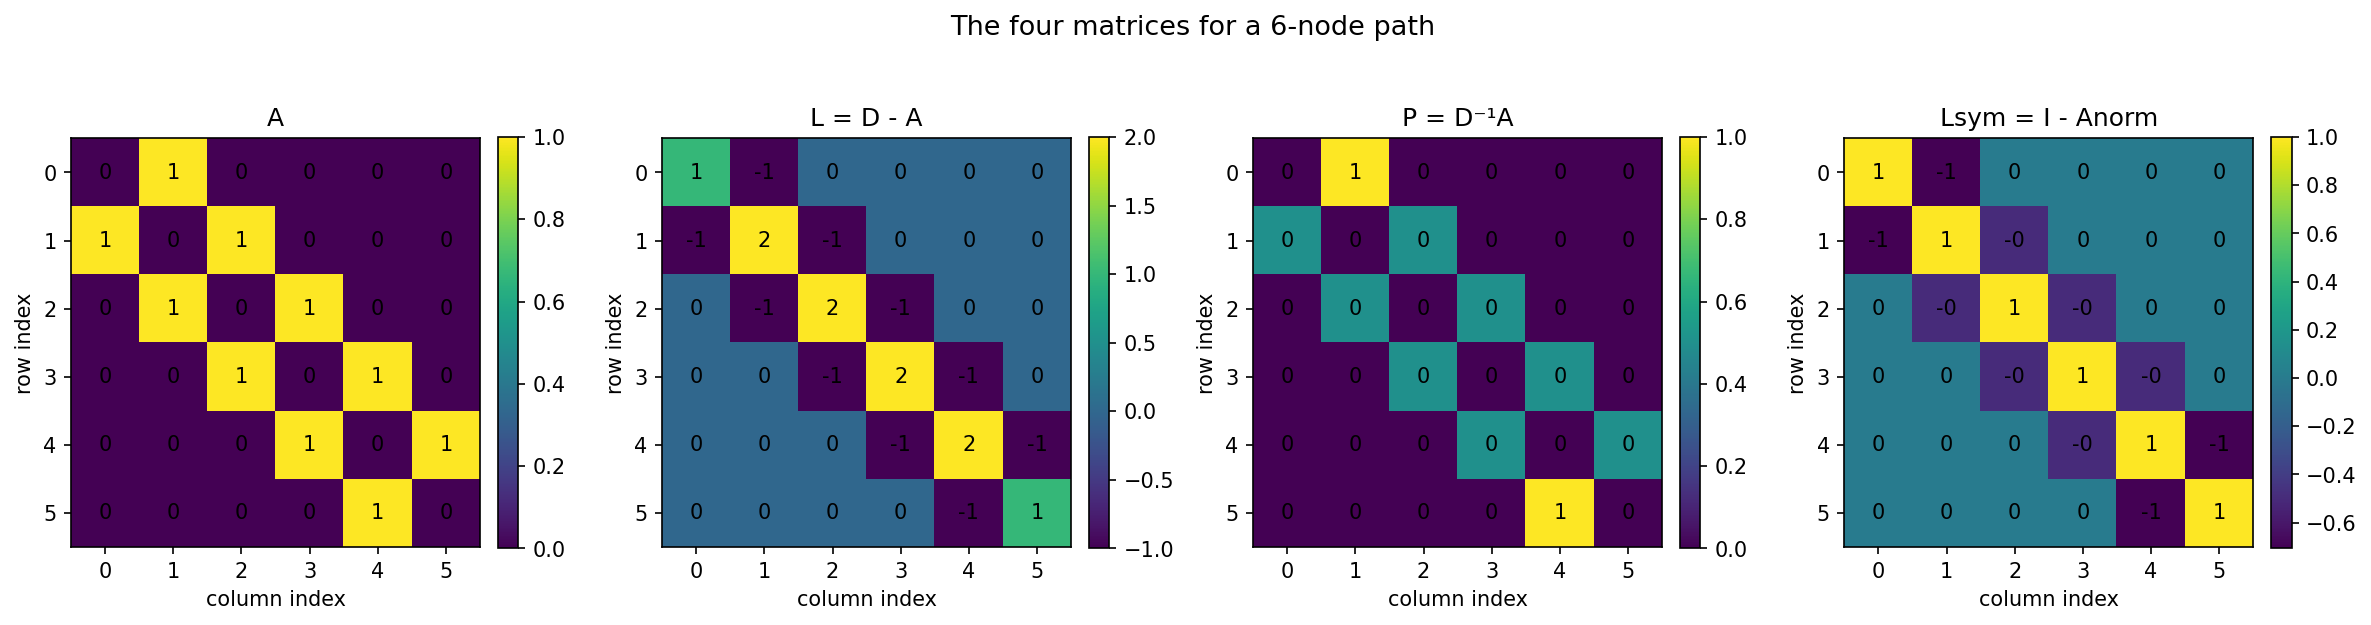

In [47]:
# Demonstrate all four matrices on the path graph
A_demo = A_path.copy()
L_demo = laplacian_from_adjacency(A_demo)
A_norm_demo = normalized_adjacency(A_demo)
L_sym_demo = normalized_laplacian_sym(A_demo)
P_demo = random_walk_matrix(A_demo)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=150)
for ax, (M, name) in zip(axes, [(A_demo, "A"), (L_demo, "L = D - A"),
                                  (P_demo, "P = D⁻¹A"), (L_sym_demo, "Lsym = I - Anorm")]):
    plot_matrix_heatmap(M, ax, title=name, ticklabels=nodes_path, annotate=True)

plt.suptitle("The four matrices for a 6-node path", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5.2 A key relationship: $L_{\text{sym}} = I - A_{\text{norm}}$

This is the single most important identity for spectral graph theory. It means:

- If $\mathbf{v}$ is an eigenvector of $A_{\text{norm}}$ with eigenvalue $\mu$, then it's also an eigenvector of $L_{\text{sym}}$ with eigenvalue $1 - \mu$.
- The **largest** eigenvalue of $A_{\text{norm}}$ corresponds to the **smallest** eigenvalue of $L_{\text{sym}}$ (which is 0).
- You only need to compute one spectrum to know the other.

In [48]:
# Verify the relationship
vals_Anorm, vecs_Anorm = eigh_sorted(A_norm_demo)
vals_Lsym, vecs_Lsym = eigh_sorted(L_sym_demo)

print("A_norm eigenvalues:   ", np.round(vals_Anorm, 4))
print("L_sym eigenvalues:    ", np.round(vals_Lsym, 4))
print("1 - A_norm eigenvals: ", np.round(1 - vals_Anorm[::-1], 4))
print("\nL_sym eigenvalues == 1 - (reversed A_norm eigenvalues)?",
      np.allclose(vals_Lsym, 1 - vals_Anorm[::-1]))

A_norm eigenvalues:    [-1.    -0.809 -0.309  0.309  0.809  1.   ]
L_sym eigenvalues:     [0.    0.191 0.691 1.309 1.809 2.   ]
1 - A_norm eigenvals:  [0.    0.191 0.691 1.309 1.809 2.   ]

L_sym eigenvalues == 1 - (reversed A_norm eigenvalues)? True


---

# Part 6 — Reading the Laplacian Spectrum

The Laplacian is the workhorse matrix for structural analysis. Let's learn to read its spectrum like a dashboard.

## 6.1 The Laplacian quadratic form is the roughness measure

Remember the roughness function from Part 1? It turns out there's a beautiful identity:

$$\mathbf{x}^\top L \mathbf{x} = \sum_{(u,v) \in E} (x_u - x_v)^2$$

The left side is a matrix multiplication. The right side is our "sum of squared neighbor differences." They are the same thing.

This is called the **Laplacian quadratic form**, and it's why the Laplacian is the right matrix for measuring smoothness.

In [49]:
def laplacian_quadratic_form(L, x):
    """Compute x^T L x."""
    x = np.asarray(x, dtype=float).ravel()
    return float(x @ L @ x)

# Verify the identity on our three test signals
for name, signal in [("constant", x_constant), ("ramp", x_ramp), ("zigzag", x_zigzag)]:
    qf = laplacian_quadratic_form(L_path, signal)
    edge_sum = roughness(G_path6, signal)
    print(f"{name:10s}:  x^T L x = {qf:6.1f},   Σ(xu-xv)² = {edge_sum:6.1f},   match: {np.isclose(qf, edge_sum)}")

constant  :  x^T L x =    0.0,   Σ(xu-xv)² =    0.0,   match: True
ramp      :  x^T L x =    5.0,   Σ(xu-xv)² =    5.0,   match: True
zigzag    :  x^T L x =   20.0,   Σ(xu-xv)² =   20.0,   match: True


## 6.2 Connected components live in the nullspace

The Laplacian always has eigenvalue 0 (the constant signal has zero roughness). But here's the key fact:

> **The multiplicity of eigenvalue 0 equals the number of connected components.**

Each connected component contributes one "constant" eigenvector (constant within the component, zero outside it).

Number of connected components: 2
Number of zero eigenvalues:     2
All eigenvalues: [-0.     -0.      0.5858  2.      2.      2.      3.4142  4.    ]


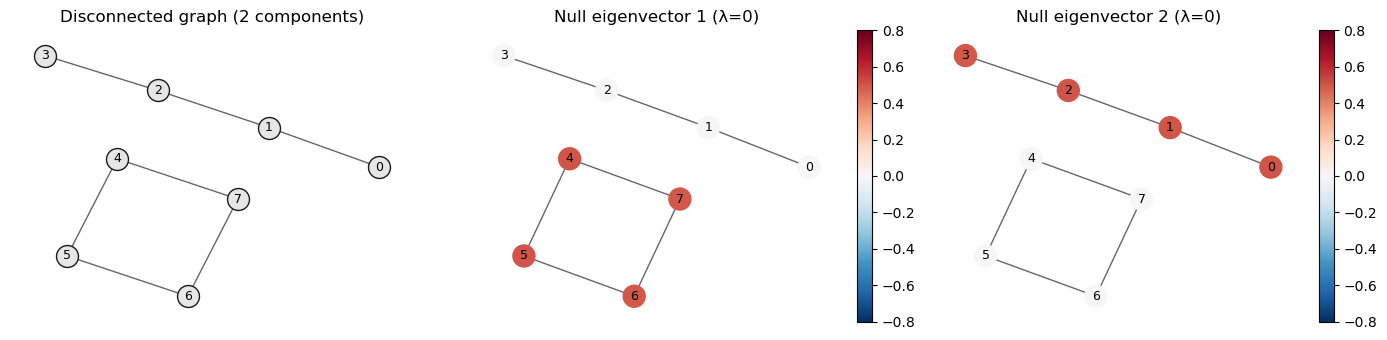


Each null eigenvector is constant within one component and zero in the other.
This tells us both THAT the graph is disconnected and WHERE the components are.


In [50]:
# Demonstrate on the disconnected graph (two components)
A_disc, nodes_disc = adjacency_dense(G_disc)
L_disc = laplacian_from_adjacency(A_disc)
vals_disc, vecs_disc = eigh_sorted(L_disc)

num_components = nx.number_connected_components(G_disc)
zero_eigenvalues = np.sum(np.abs(vals_disc) < 1e-10)

print(f"Number of connected components: {num_components}")
print(f"Number of zero eigenvalues:     {zero_eigenvalues}")
print(f"All eigenvalues: {np.round(vals_disc, 4)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), dpi=100)

pos_disc = nx.kamada_kawai_layout(G_disc)
draw_graph(G_disc, axes[0], pos=pos_disc, title="Disconnected graph (2 components)")

# Show the two zero-eigenvalue eigenvectors
for k in range(2):
    vec = normalize_sign(vecs_disc[:, k])
    draw_graph(G_disc, axes[k+1], pos=pos_disc, values=vec,
               title=f"Null eigenvector {k+1} (λ=0)",
               cmap="RdBu_r", vmin=-0.8, vmax=0.8)

plt.tight_layout()
plt.show()

print("\nEach null eigenvector is constant within one component and zero in the other.")
print("This tells us both THAT the graph is disconnected and WHERE the components are.")

## 6.3 Spectra as fingerprints: comparing graph families

Now let's compare the full Laplacian spectra of our four graph families. Each spectrum is a fingerprint of the graph's shape.

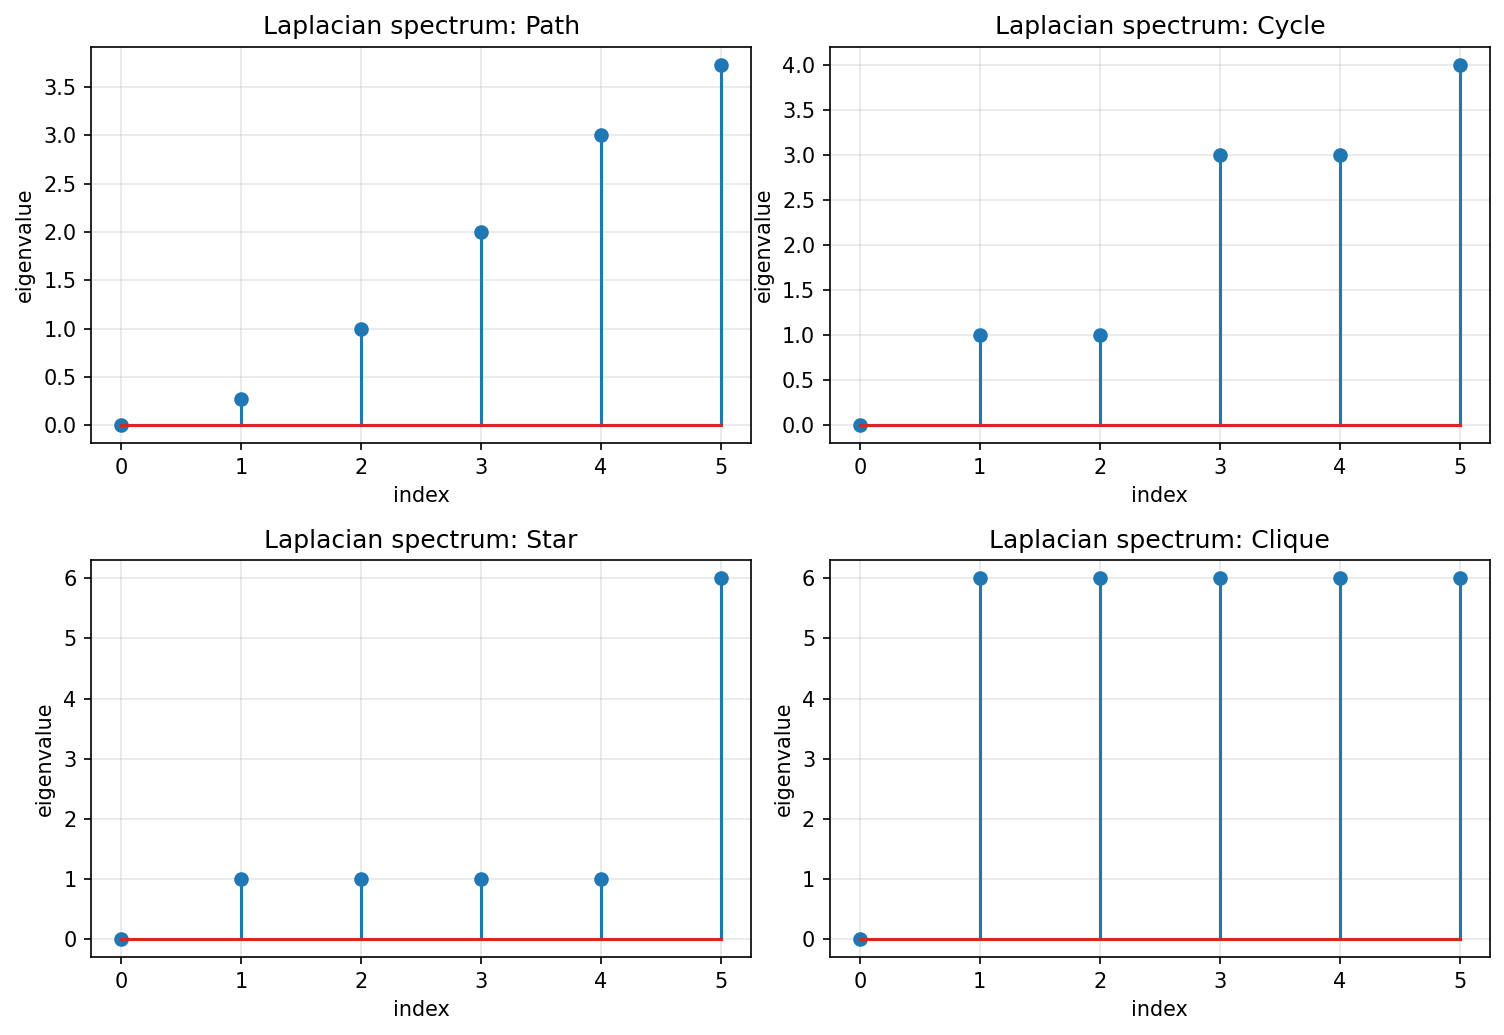

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=150)
axes = axes.ravel()

for ax, (name, G) in zip(axes, graphs.items()):
    A_fam, _ = adjacency_dense(G)
    L_fam = laplacian_from_adjacency(A_fam)
    vals_fam, _ = eigh_sorted(L_fam)
    ax.stem(np.arange(len(vals_fam)), vals_fam)
    ax.set_title(f"Laplacian spectrum: {name}")
    ax.set_xlabel("index")
    ax.set_ylabel("eigenvalue")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

What can we read from these?

- **All start at 0** — every connected graph has exactly one zero eigenvalue.
- **Path**: eigenvalues rise gradually — many different frequency modes, from slow to fast.
- **Cycle**: similar to path but with *paired* eigenvalues (the two directions around the ring).
- **Star**: one small eigenvalue, then a cluster of equal eigenvalues at $n$, then one at $n+1$. Very different from the path despite having the same number of nodes.
- **Clique**: the smallest non-zero eigenvalue is already large ($= n$), and all $n-1$ non-zero eigenvalues are equal. The clique has no "slow" modes — all vibrations are equally rough.

## 6.4 Graph Fourier modes: low-pass and high-pass

Since the eigenvectors are vibration modes sorted by frequency, we can do **filtering**. Want to keep only the smooth, large-scale structure of a signal? Keep the low-frequency eigenvectors and throw away the rest. This is the graph analogue of a low-pass filter.

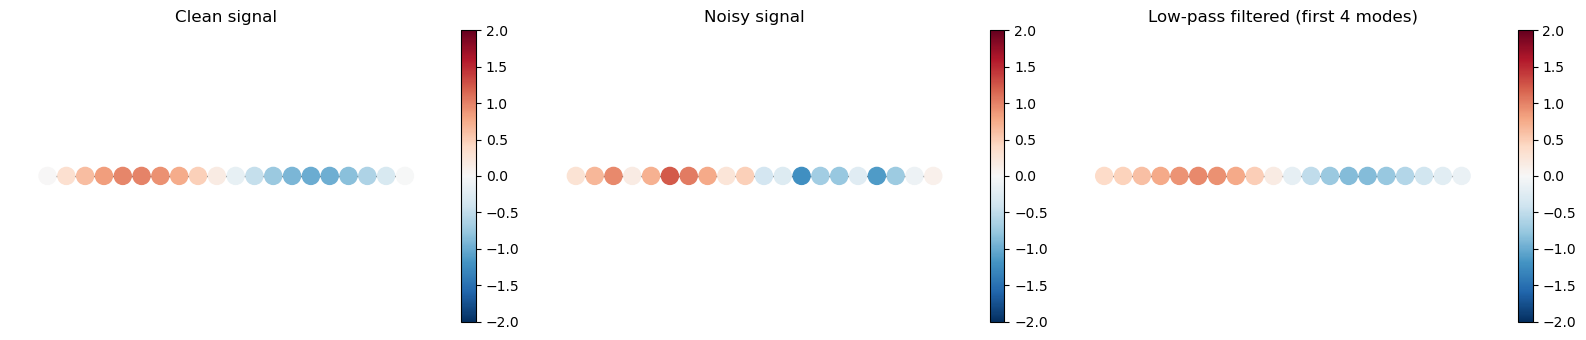

The low-pass filter recovers the smooth structure by discarding high-frequency modes.
This is the graph Fourier transform in action.


In [52]:
# Create a noisy signal on a larger path graph
G_path20 = nx.path_graph(20)
A_p20, nodes_p20 = adjacency_dense(G_path20)
L_p20 = laplacian_from_adjacency(A_p20)
vals_p20, vecs_p20 = eigh_sorted(L_p20)

# Smooth signal + noise
x_clean = np.sin(np.linspace(0, 2 * np.pi, 20))
x_noisy = x_clean + 0.5 * rng.standard_normal(20)

# Project onto eigenvectors (graph Fourier transform)
coeffs = vecs_p20.T @ x_noisy  # Fourier coefficients

# Low-pass: keep only first k modes
k = 4
x_lowpass = vecs_p20[:, :k] @ coeffs[:k]

pos_p20 = {i: (i, 0) for i in range(20)}

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5), dpi=100)

draw_graph(G_path20, axes[0], pos=pos_p20, values=x_clean,
           title="Clean signal", cmap="RdBu_r", with_labels=False, node_size=150,
           vmin=-2, vmax=2)
draw_graph(G_path20, axes[1], pos=pos_p20, values=x_noisy,
           title="Noisy signal", cmap="RdBu_r", with_labels=False, node_size=150,
           vmin=-2, vmax=2)
draw_graph(G_path20, axes[2], pos=pos_p20, values=x_lowpass,
           title=f"Low-pass filtered (first {k} modes)", cmap="RdBu_r",
           with_labels=False, node_size=150, vmin=-2, vmax=2)

plt.tight_layout()
plt.show()

print("The low-pass filter recovers the smooth structure by discarding high-frequency modes.")
print("This is the graph Fourier transform in action.")

## Your turn!

Choose two signals on the **cycle graph**: one that is smooth and one that alternates sharply from node to node. Compute $\mathbf{x}^\top L \mathbf{x}$ for both.

**Before you run the code:** which one should have the larger quadratic form?

In [53]:
# Reference solution
A_cycle, nodes_cycle = adjacency_dense(G_cycle6)
L_cycle = laplacian_from_adjacency(A_cycle)

x_smooth = np.array([0, 1, 2, 2, 1, 0], dtype=float)
x_rough = np.array([1, -1, 1, -1, 1, -1], dtype=float)

q_smooth = laplacian_quadratic_form(L_cycle, x_smooth)
q_rough = laplacian_quadratic_form(L_cycle, x_rough)

print(f"Smooth signal: x^T L x = {q_smooth}")
print(f"Rough signal:  x^T L x = {q_rough}")
print(f"\nThe rough signal has {q_rough/q_smooth:.1f}x more roughness — as expected!")

Smooth signal: x^T L x = 4.0
Rough signal:  x^T L x = 24.0

The rough signal has 6.0x more roughness — as expected!


---

# Summary

What we covered:

| Concept | Key idea |
|:---|:---|
| **Spectrum as fingerprint** | A network's eigenvalues are a structural signature, like an emission spectrum |
| **Signals on graphs** | A node signal is a vector $\mathbf{x} \in \mathbb{R}^n$; matrices act on signals |
| **Roughness** | $\sum_{(u,v)} (x_u - x_v)^2 = \mathbf{x}^\top L \mathbf{x}$ measures neighbor disagreement |
| **Eigenvectors** | Signals whose shape is preserved by the matrix: $M\mathbf{v} = \lambda\mathbf{v}$ |
| **Eigenvalues** | Scale factors = frequencies = roughness of each mode |
| **Four matrices** | $A$ (walks/centrality), $L$ (smoothness/cuts), $P$ (random walks), $L_{\text{sym}}$ (clustering) |
| **Components** | Number of zero Laplacian eigenvalues = number of connected components |
| **Graph Fourier** | Any signal = sum of eigenvector modes; low-pass filtering removes noise |

**Next time (Class 11b):** We'll use this machinery for adjacency spectra & centrality, the Fiedler vector & graph cuts, random walks & the spectral gap, and spectral clustering.

---

# Appendix: Matrix-vector multiplication as neighbor aggregation

This section provides a deeper look at the basic operation that underlies everything above.

If $\mathbf{x}$ is a signal on the nodes and $A$ is the adjacency matrix, then the product $\mathbf{y} = A\mathbf{x}$ has a very concrete interpretation:

$$y_i = \sum_{j=1}^{n} A_{ij}\, x_j = \sum_{\text{neighbors } j \text{ of } i} x_j$$

In words: **the new value at node $i$ is the sum of the old values on $i$'s neighbors.**

The symbols:

| Symbol | What it represents |
|:---|:---|
| $x_j$ | the signal value currently sitting on node $j$ |
| $A_{ij}$ | 1 if there is an edge $(i,j)$, 0 otherwise — acts as a selector |
| $y_i$ | the result at node $i$: the sum of signal values on $i$'s neighbors |

In [54]:
# Verify: matrix multiplication vs manual neighbor sum
x_demo = np.array([10, 20, 30, 40, 50, 60], dtype=float)

# Matrix multiplication
y_matrix = A_path @ x_demo

# Manual neighbor sums
y_manual = np.zeros(6)
for i in range(6):
    for j in G_path6.neighbors(i):
        y_manual[i] += x_demo[j]

df = pd.DataFrame({
    'node': range(6),
    'x (signal)': x_demo,
    'Ax (matrix)': y_matrix,
    'neighbor sum (manual)': y_manual,
    'match': np.isclose(y_matrix, y_manual)
})
display(df)
print("\nThey match perfectly — Ax IS the neighbor sum.")

,node,x (signal),Ax (matrix),neighbor sum (manual),match
0,0,10.0,20.0,20.0,True
1,1,20.0,40.0,40.0,True
2,2,30.0,60.0,60.0,True
3,3,40.0,80.0,80.0,True
4,4,50.0,100.0,100.0,True
5,5,60.0,50.0,50.0,True



They match perfectly — Ax IS the neighbor sum.


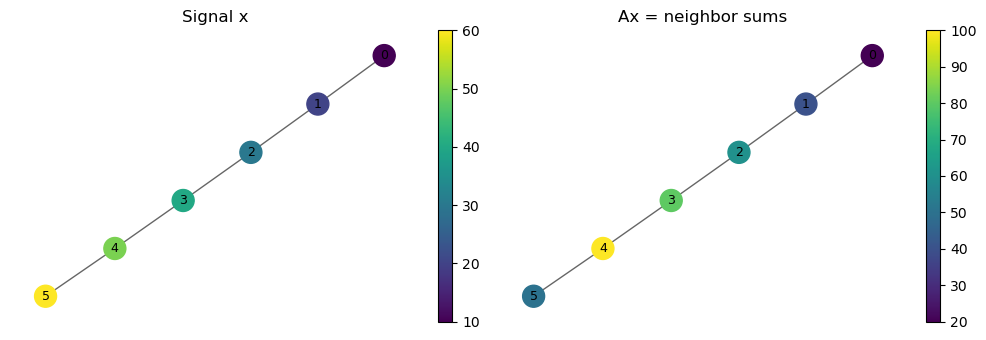

In [55]:
# Visualize the signal before and after multiplication
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=100)

draw_graph(G_path6, axes[0], pos=pos_path, values=x_demo,
           title="Signal x", cmap="viridis")
draw_graph(G_path6, axes[1], pos=pos_path, values=y_matrix,
           title="Ax = neighbor sums", cmap="viridis")

plt.tight_layout()
plt.show()

# Appendix: Matrix powers count walks

A beautiful consequence of the neighbor-sum interpretation: if $A\mathbf{x}$ sums over neighbors (1-step), then $A^2\mathbf{x}$ sums over 2-step neighbors, and in general:

> $(A^\ell)_{ij}$ = the number of walks of length $\ell$ from node $i$ to node $j$.

This is why the adjacency matrix is so useful for understanding connectivity.

In [56]:
def count_walks_by_enumeration(G, start, length):
    """Brute-force walk counting for tiny graphs."""
    counts = {start: 1}
    for _ in range(length):
        new_counts = {u: 0 for u in G.nodes()}
        for u, c in counts.items():
            for v in G.neighbors(u):
                new_counts[v] += c
        counts = new_counts
    return counts

# A^2 and A^3 for the path graph
A2 = np.linalg.matrix_power(A_path, 2)
A3 = np.linalg.matrix_power(A_path, 3)

print("A² (number of length-2 walks between each pair):")
show_matrix_df(A2, index=nodes_path, columns=nodes_path)

# Verify one entry
walks_from_0 = count_walks_by_enumeration(G_path6, start=0, length=2)
print(f"\nBrute-force: length-2 walks from node 0: {walks_from_0}")
print(f"Matrix:      A²[0,:] = {A2[0,:].astype(int)}")
print("Match!")

A² (number of length-2 walks between each pair):


,0,1,2,3,4,5
0,1.0,0.0,1.0,0.0,0.0,0.0
1,0.0,2.0,0.0,1.0,0.0,0.0
2,1.0,0.0,2.0,0.0,1.0,0.0
3,0.0,1.0,0.0,2.0,0.0,1.0
4,0.0,0.0,1.0,0.0,2.0,0.0
5,0.0,0.0,0.0,1.0,0.0,1.0



Brute-force: length-2 walks from node 0: {0: 1, 1: 0, 2: 1, 3: 0, 4: 0, 5: 0}
Matrix:      A²[0,:] = [1 0 1 0 0 0]
Match!


### Your turn!

On the same path graph, compute $A^4$ and interpret one entry in words. Pick indices $i$ and $j$, and explain what $(A^4)_{ij}$ is counting before you run the solution.

A good choice: look at one **diagonal** entry and one **off-diagonal** entry. The diagonal entry counts *closed walks* of length four.

In [57]:
A4 = np.linalg.matrix_power(A_path, 4)
show_matrix_df(A4, name="A^4 for the path graph", index=nodes_path, columns=nodes_path)

i, j = 2, 2
counts_len4 = count_walks_by_enumeration(G_path6, start=i, length=4)

print(f"\n(A^4)[{i}, {j}] = {A4[i, j]:.0f}")
print(f"Brute-force count: {counts_len4[j]}")
print(f"Interpretation: there are {A4[i, j]:.0f} length-4 closed walks starting and ending at node {i}.")

A^4 for the path graph


,0,1,2,3,4,5
0,2.0,0.0,3.0,0.0,1.0,0.0
1,0.0,5.0,0.0,4.0,0.0,1.0
2,3.0,0.0,6.0,0.0,4.0,0.0
3,0.0,4.0,0.0,6.0,0.0,3.0
4,1.0,0.0,4.0,0.0,5.0,0.0
5,0.0,1.0,0.0,3.0,0.0,2.0



(A^4)[2, 2] = 6
Brute-force count: 6
Interpretation: there are 6 length-4 closed walks starting and ending at node 2.
